# Nonlinear Analysis of EEG Signals

In this notebook, we explore nonlinear methods for analyzing electroencephalography (EEG) signals and compare them with conventional linear approaches. We examine concepts such as stationarity, phase-space reconstruction, complexity, and chaos.

The notebook is organized around two commonly used EEG paradigms:

- **Eyes open vs. eyes closed** – resting-state EEG recorded over the occipital cortex using channels **O1** and **O2**, where prominent changes in alpha activity are expected.
- **Motor imagery** – imagined movements of the **both hands** and **both feet**, analyzed using channels **C3**, **Cz**, and **C4**, which cover the sensorimotor cortex.


**Data:** PhysioNet EEG Motor Movement/Imagery Dataset (EEGMMIDB): https://www.physionet.org/content/eegmmidb/1.0.0/

- Run mapping:

        - 1 = baseline eyes open
        - 2 = baseline eyes closed
        - 3, 7, 11 = executed left/right hand
        - 4, 8, 12 = imagined left/right hand
        - 5, 9, 13 = executed hands/feet
        - 6, 10, 14 = imagined hands/feet

- Alternative site (same dataset): https://moabb.neurotechx.com/docs/generated/moabb.datasets.PhysionetMI.html

## 1. Eyes open/closed

- Done on entire recording (since recording is during a stable state - eyes open the entire time or eyes closed the entire time):

| Step               | What is shown |
|:-------------------|:--------------|
| Raw EEG            | O1/O2 segment from eyes open and eyes closed recordings |
| Stationarity       | Windowed mean and variance over time |
| PSD                | Welch PSD, 1–40 Hz |
| Phase space        | Autocorrelation (τ selection), false nearest neighbors (m selection), 2D/3D reconstruction, band-specific phase spaces |
| Feature extraction | Variance, alpha power (8–13 Hz), sample entropy, Higuchi fractal dimension, correlation dimension, largest Lyapunov exponent |

### 1.1. Raw EEG

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R02.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =   

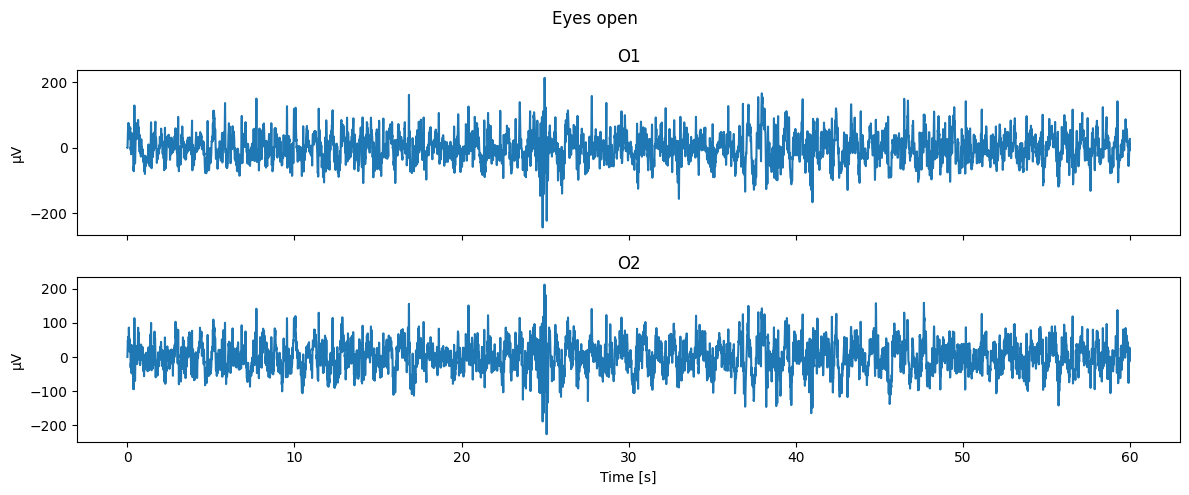

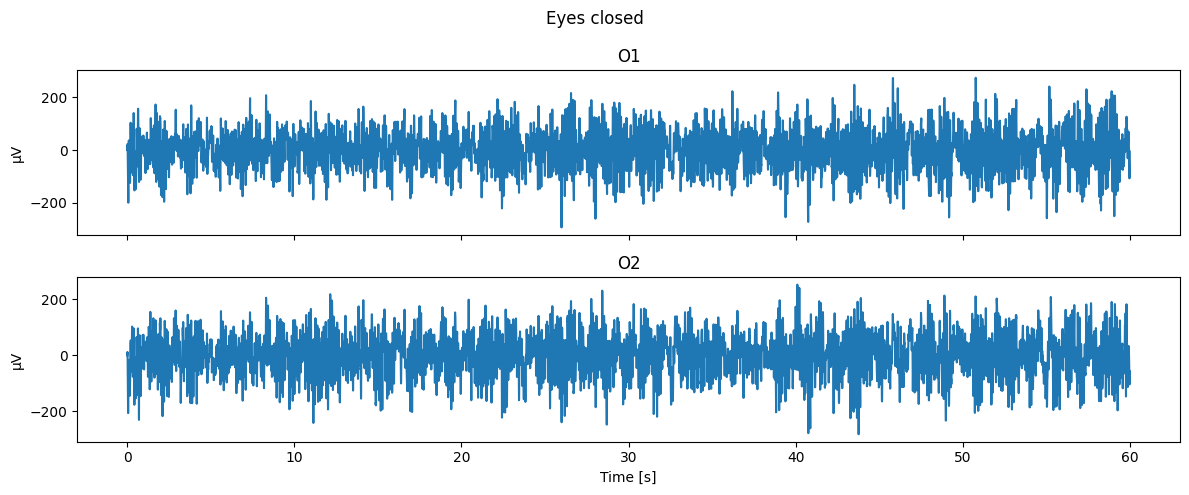

In [30]:
from matplotlib import pyplot as plt
import mne
from mne.io import read_raw_edf
from mne.datasets import eegbci

subject = 1
runs = [1, 2]  # 1 = eyes open, 2 = eyes closed according to MOABB EEGMMIDB mapping
channels = ["O1", "O2"]

condition_names = {
    1: "Eyes open",
    2: "Eyes closed"
}


def load_eegmmidb_run(subject, run, l_freq=1.0, h_freq=40.0):
    file = eegbci.load_data(subject, [run])[0]
    raw = read_raw_edf(file, preload=True)

    eegbci.standardize(raw)

    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage)

    raw.pick("eeg")
    raw.filter(l_freq, h_freq, fir_design="firwin")

    return raw


raws = {
    condition_names[run]: load_eegmmidb_run(subject, run)
    for run in runs
}

for name, raw in raws.items():
    print(f"\n{name}")
    print(raw)
    print(raw.annotations)


def plot_raw_segment(raw, condition, channels, start_sec=10, duration_sec=8):
    sfreq = raw.info["sfreq"]

    data, times = raw.copy().pick(channels).get_data(
        start=int(start_sec * sfreq),
        stop=int((start_sec + duration_sec) * sfreq),
        return_times=True
    )


    fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

    for i, ch in enumerate(channels):
        axes[i].plot(times, data[i] * 1e6)
        axes[i].set_title(ch)
        axes[i].set_ylabel("µV")

    axes[-1].set_xlabel("Time [s]")
    plt.suptitle(condition)
    plt.tight_layout()
    plt.show()

for condition, raw in raws.items():
    plot_raw_segment(raw, condition, channels, start_sec=0 , duration_sec=60)   #entire recording




### 1.2 PSD

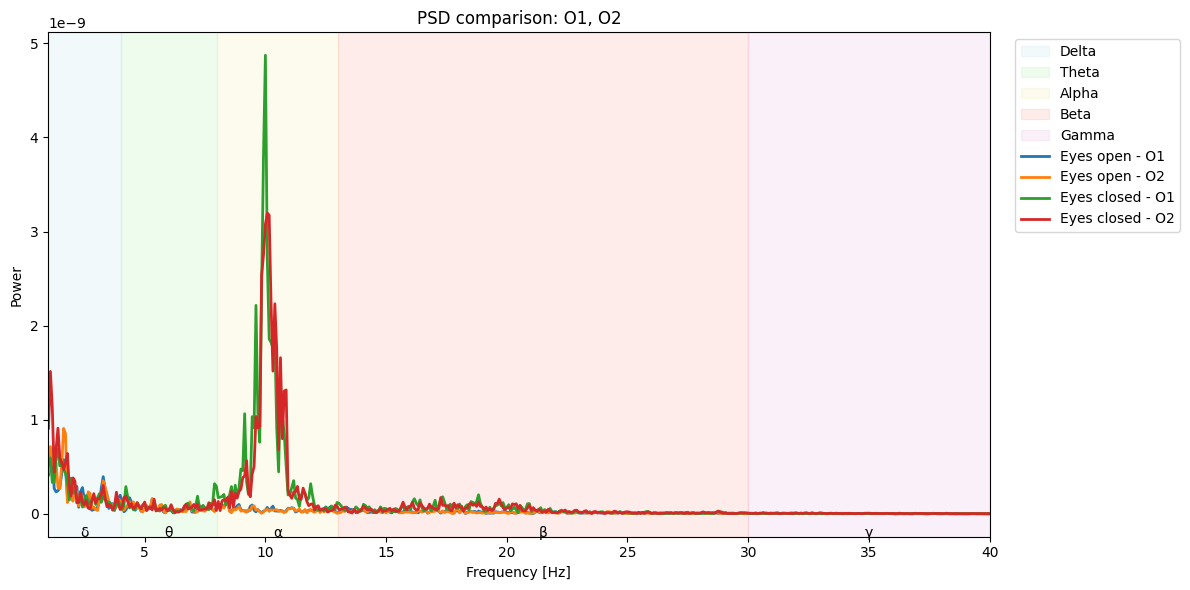

In [31]:
def plot_psd_comparison(raws, channels, fmin=1, fmax=40):
    plt.figure(figsize=(12, 6))

    bands = {
        "Delta": (1, 4),
        "Theta": (4, 8),
        "Alpha": (8, 13),
        "Beta": (13, 30),
        "Gamma": (30, 40),
    }

    # Shade frequency bands
    colors = ["lightblue", "lightgreen", "khaki", "salmon", "plum"]
    for (name, (low, high)), color in zip(bands.items(), colors):
        plt.axvspan(low, high, color=color, alpha=0.15, label=name)


    for condition, raw in raws.items():
        psd = raw.compute_psd(
            method="welch",
            fmin=fmin,
            fmax=fmax,
            picks=channels,
            verbose=False
        )

        freqs = psd.freqs
        power = psd.get_data()

        for ch, p in zip(channels, power):
            plt.plot(freqs, p, linewidth=2, label=f"{condition} - {ch}")

    plt.title(f"PSD comparison: {', '.join(channels)}")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Power")
    plt.xlim(fmin, fmax)

    ymin = plt.ylim()[0]
    plt.text(2.5, ymin, "δ", ha="center")
    plt.text(6, ymin, "θ", ha="center")
    plt.text(10.5, ymin, "α", ha="center")
    plt.text(21.5, ymin, "β", ha="center")
    plt.text(35, ymin, "γ", ha="center")

    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_psd_comparison(raws, channels)

> **Observation:** A pronounced **alpha rhythm (8–13 Hz)** is clearly visible in the **eyes-closed** condition over the occipital electrodes. This reflects synchronized activity of the visual cortex when external visual input is absent. In the **eyes-open** condition, the alpha peak largely disappears due to alpha desynchronization, while only a modest increase in **delta/theta** band remains.

### 1.3. Stationarity & phase space

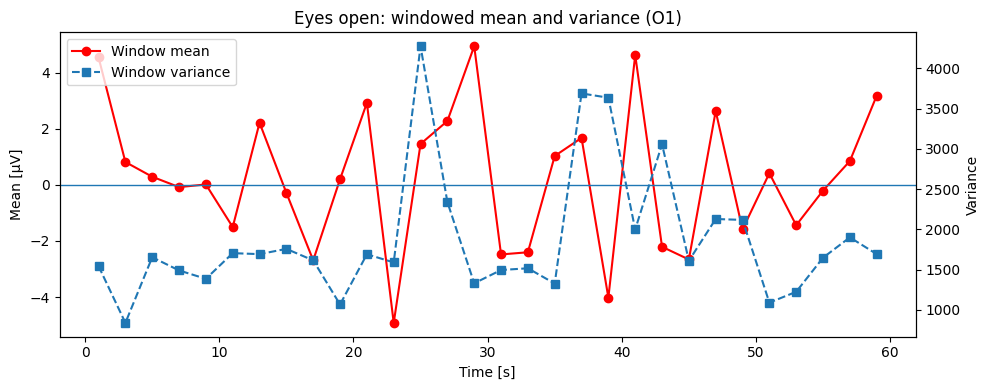

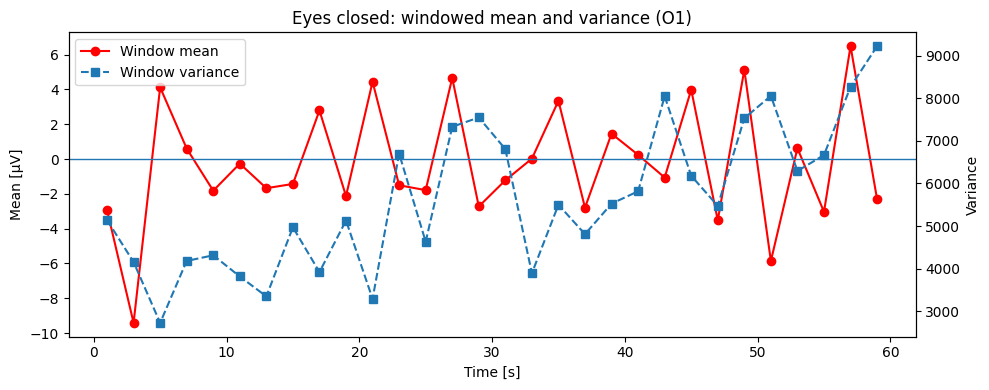

In [32]:
import pandas as pd
import numpy as np


def compute_stationarity(raws, channel="O1", window_sec=2.0):
    rows = []

    for condition, raw in raws.items():
        sfreq = raw.info["sfreq"]
        x = raw.copy().pick([channel]).get_data()[0] * 1e6  # µV

        window_len = int(window_sec * sfreq)
        n_windows = len(x) // window_len

        for w in range(n_windows):
            start = w * window_len
            stop = start + window_len
            segment = x[start:stop]

            rows.append({
                "condition": condition,
                "channel": channel,
                "window": w,
                "start_sec": start / sfreq,
                "end_sec": stop / sfreq,
                "mean": np.mean(segment),
                "variance": np.var(segment),
            })

    return pd.DataFrame(rows)

stationarity = compute_stationarity(raws, channel="O1", window_sec=2.0)


def plot_window_mean_variance(stationarity, condition):
    df = stationarity[stationarity["condition"] == condition].copy()
    centers = (df["start_sec"] + df["end_sec"]) / 2

    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(centers, df["mean"], marker="o", label="Window mean", color="red")
    ax1.axhline(0, linewidth=1)
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("Mean [µV]")

    ax2 = ax1.twinx()
    ax2.plot(centers, df["variance"], marker="s", linestyle="--", label="Window variance")
    ax2.set_ylabel("Variance")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    plt.title(f"{condition}: windowed mean and variance (O1)")
    plt.tight_layout()
    plt.show()

for condition, raw in raws.items():
    plot_window_mean_variance(stationarity, condition)

*Observation: The signal appears approximately stationary with respect to its mean and variance, although the variance is not perfectly constant.*

Eyes open
First local minimum: τ = 31 samples (0.194 s)
First zero crossing: τ = 25 samples (0.156 s)
Eyes closed
First local minimum: τ = 8 samples (0.050 s)
First zero crossing: τ = 5 samples (0.031 s)


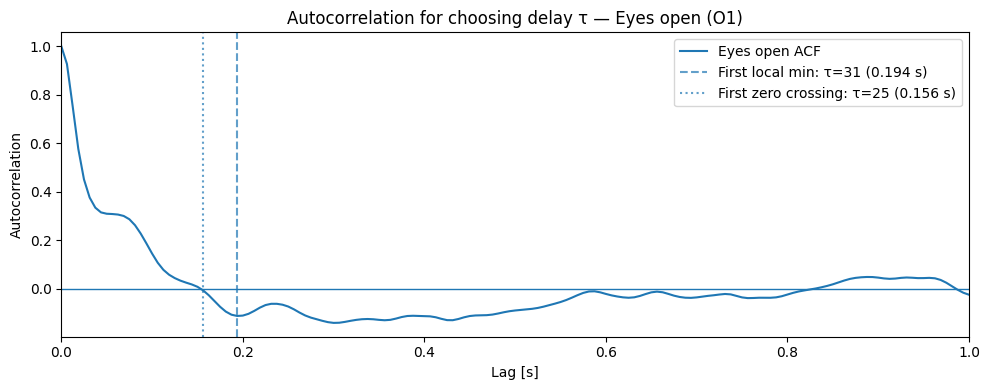

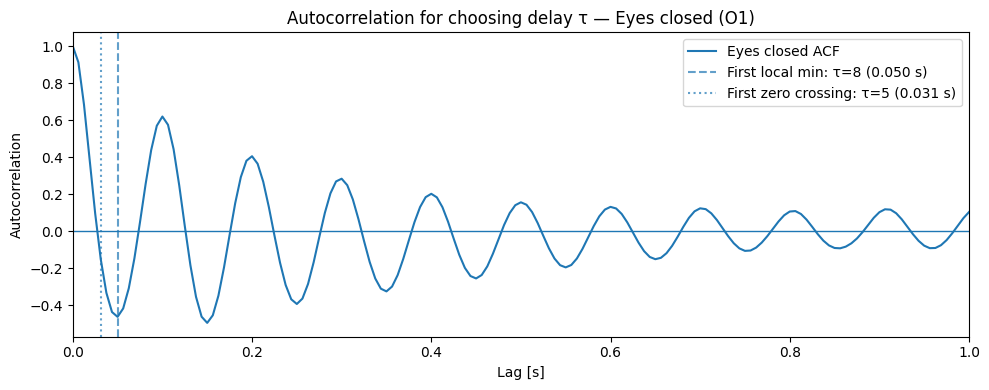

In [33]:
def autocorrelation(x, max_lag):
    x = np.asarray(x)
    x = x - np.mean(x)

    acf_full = np.correlate(x, x, mode="full")
    acf = acf_full[len(x)-1:len(x)-1 + max_lag + 1]
    acf = acf / acf[0]

    return acf


def first_local_minimum(acf):
    for i in range(1, len(acf) - 1):
        if acf[i] < acf[i - 1] and acf[i] < acf[i + 1]:
            return i
    return None


def first_zero_crossing(acf):
    crossing = np.where(acf <= 0)[0]
    return int(crossing[0]) if len(crossing) else None


analysis_channel = "O1"
max_lag_sec = 1.0

acf_results = {}

for condition, raw in raws.items():
    sfreq = raw.info["sfreq"]
    x = raw.copy().pick([analysis_channel]).get_data()[0] * 1e6

    max_lag = int(max_lag_sec * sfreq)
    acf = autocorrelation(x, max_lag)

    tau_min = first_local_minimum(acf)
    tau_zero = first_zero_crossing(acf)

    acf_results[condition] = {
        "acf": acf,
        "tau_first_min": tau_min,
        "tau_first_zero": tau_zero,
        "sfreq": sfreq,
    }

    print(condition)
    print(f"First local minimum: τ = {tau_min} samples ({tau_min/sfreq:.3f} s)")
    print(f"First zero crossing: τ = {tau_zero} samples ({tau_zero/sfreq:.3f} s)")



def plot_acf_results_sep (acf_results, max_lag_sec=1.0):
    for condition, res in acf_results.items():
        acf = res["acf"]
        sfreq = res["sfreq"]
        lags_sec = np.arange(len(acf)) / sfreq

        plt.figure(figsize=(10, 4))

        plt.plot(lags_sec, acf, label=f"{condition} ACF")
        plt.axhline(0, linewidth=1)

        tau_min = res["tau_first_min"]
        if tau_min is not None:
            plt.axvline(
                tau_min / sfreq,
                linestyle="--",
                alpha=0.7,
                label=f"First local min: τ={tau_min} ({tau_min/sfreq:.3f} s)"
            )

        tau_zero = res["tau_first_zero"]
        if tau_zero is not None:
            plt.axvline(
                tau_zero / sfreq,
                linestyle=":",
                alpha=0.7,
                label=f"First zero crossing: τ={tau_zero} ({tau_zero/sfreq:.3f} s)"
            )

        plt.xlim(0, max_lag_sec)
        plt.xlabel("Lag [s]")
        plt.ylabel("Autocorrelation")
        plt.title(f"Autocorrelation for choosing delay τ — {condition} (O1)")
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_acf_results_sep(acf_results, max_lag_sec=max_lag_sec)



In [34]:
analysis_channel = "O2"
acf_results = {}

for condition, raw in raws.items():
    sfreq = raw.info["sfreq"]
    x = raw.copy().pick([analysis_channel]).get_data()[0] * 1e6

    max_lag = int(max_lag_sec * sfreq)
    acf = autocorrelation(x, max_lag)

    tau_min = first_local_minimum(acf)
    tau_zero = first_zero_crossing(acf)

    acf_results[condition] = {
        "acf": acf,
        "tau_first_min": tau_min,
        "tau_first_zero": tau_zero,
        "sfreq": sfreq,
    }

    print(f"{condition} O2")
    print(f"First local minimum: τ = {tau_min} samples ({tau_min/sfreq:.3f} s)")
    print(f"First zero crossing: τ = {tau_zero} samples ({tau_zero/sfreq:.3f} s)")

Eyes open O2
First local minimum: τ = 32 samples (0.200 s)
First zero crossing: τ = 27 samples (0.169 s)
Eyes closed O2
First local minimum: τ = 8 samples (0.050 s)
First zero crossing: τ = 5 samples (0.031 s)


#### Choosing the embedding delay

Before reconstructing the phase space, we need to select an appropriate **time delay (τ)**. There is no single universally accepted rule for choosing τ, so in practice several heuristics are commonly used. In this notebook, we compare two widely used criteria based on the autocorrelation function (ACF):

- **First zero crossing** – the delay at which the signal becomes approximately uncorrelated with its past.
- **First local minimum** – the delay at which temporal redundancy is sufficiently reduced while preserving the underlying dynamics.



Eyes open, O1, τ=25: suggested m = 6
Eyes open, O1, τ=31: suggested m = 6
Eyes open, O1, τ=35: suggested m = 6


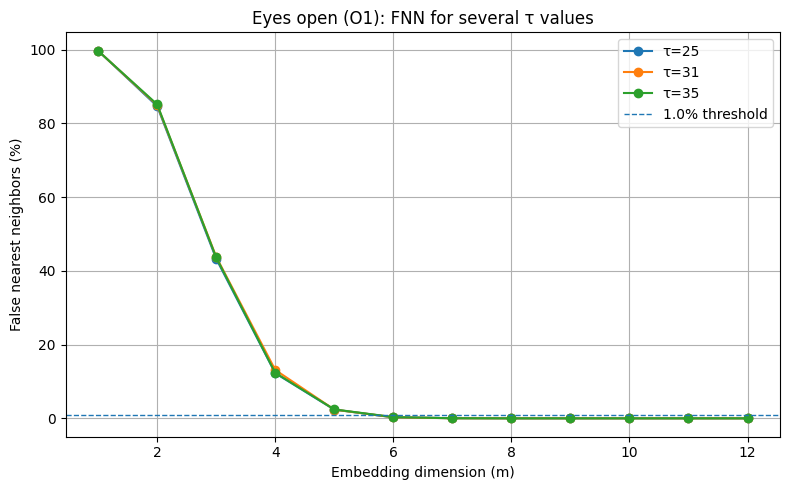

Eyes closed, O1, τ=5: suggested m = 6
Eyes closed, O1, τ=6: suggested m = 5
Eyes closed, O1, τ=8: suggested m = 6


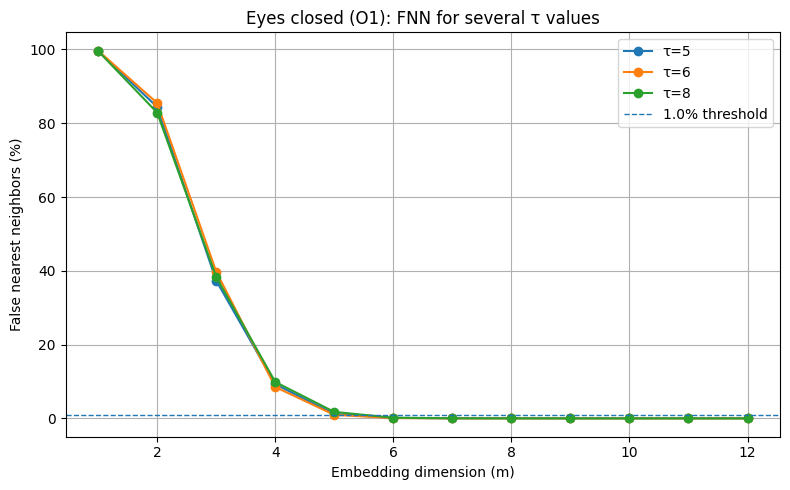

In [35]:
from sklearn.neighbors import NearestNeighbors


def delay_embedding(x, m, tau):
    N = len(x) - (m - 1) * tau
    if N <= 0:
        raise ValueError("Time series too short for requested embedding.")

    return np.column_stack(
        [x[i * tau : i * tau + N] for i in range(m)]
    )


def false_nearest_neighbors(x, tau, max_dim=15, rtol=10):
    fnn_percent = []

    for m in range(1, max_dim + 1):
        Xm = delay_embedding(x, m, tau)
        Xm1 = delay_embedding(x, m + 1, tau)

        N = min(len(Xm), len(Xm1))
        Xm = Xm[:N]
        Xm1 = Xm1[:N]

        nbrs = NearestNeighbors(n_neighbors=2).fit(Xm)
        distances, indices = nbrs.kneighbors(Xm)

        false = 0

        for i in range(N):
            nn = indices[i, 1]

            dist_m = distances[i, 1]
            if dist_m == 0:
                continue

            dist_m1 = np.linalg.norm(Xm1[i] - Xm1[nn])

            if dist_m1 / dist_m > rtol:
                false += 1

        fnn_percent.append(100 * false / N)

    return np.array(fnn_percent)


def plot_fnn_for_condition(raws, condition, channel, taus, max_dim=12, threshold=1.0):
    raw = raws[condition]
    x = raw.copy().pick([channel]).get_data()[0] * 1e6

    plt.figure(figsize=(8, 5))

    results = {}

    for tau in taus:
        fnn = false_nearest_neighbors(x, tau=tau, max_dim=max_dim)
        results[tau] = fnn

        plt.plot(
            range(1, max_dim + 1),
            fnn,
            "o-",
            label=f"τ={tau}"
        )

        below = np.where(fnn < threshold)[0]

        if len(below):
            m_opt = below[0] + 1
            print(f"{condition}, {channel}, τ={tau}: suggested m = {m_opt}")
        else:
            print(f"{condition}, {channel}, τ={tau}: no m below {threshold}%")

    plt.axhline(threshold, linestyle="--", linewidth=1, label=f"{threshold}% threshold")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False nearest neighbors (%)")
    plt.title(f"{condition} ({channel}): FNN for several τ values")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results


analysis_channel = "O1"
max_dim = 12
threshold = 1.0

tau_sets = {
    "Eyes open": [25, 31, 35],
    "Eyes closed": [5, 6, 8],
}

fnn_results = {}

for condition, taus in tau_sets.items():
    fnn_results[condition] = plot_fnn_for_condition(
        raws=raws,
        condition=condition,
        channel=analysis_channel,
        taus=taus,
        max_dim=max_dim,
        threshold=threshold
    )

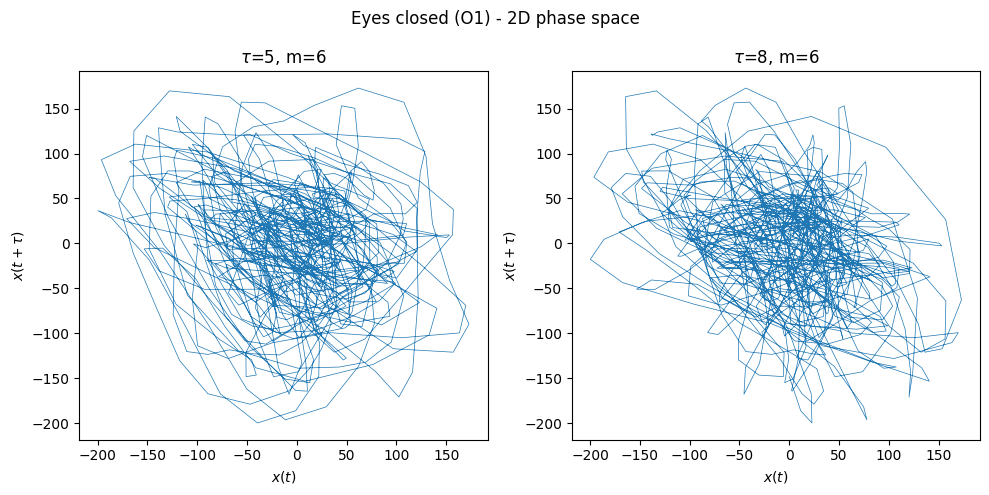

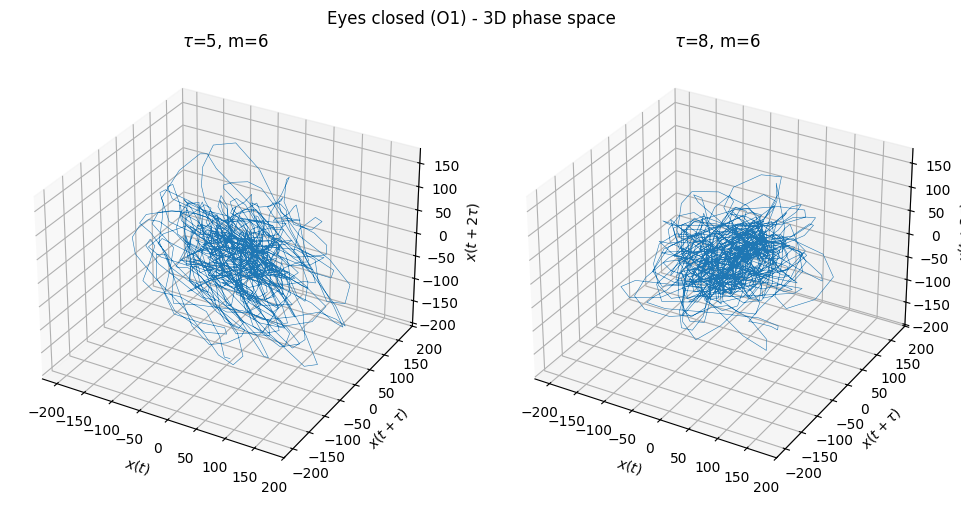

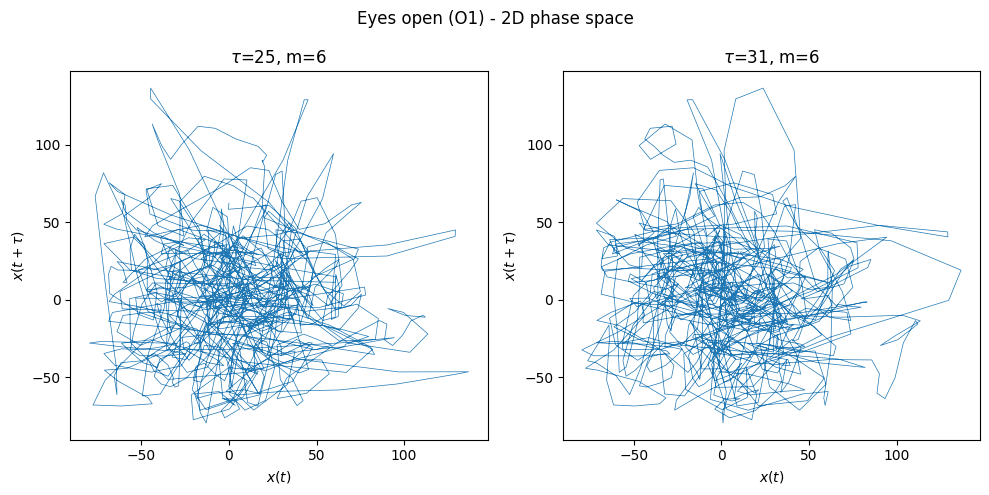

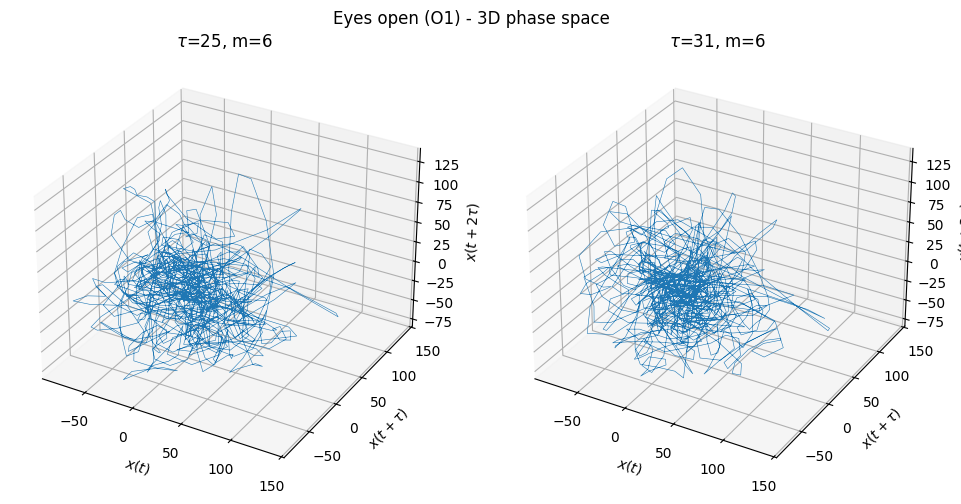

In [36]:
from mpl_toolkits.mplot3d import Axes3D

def plot_phase_space_comparison(raws, condition, channel, tau_m_pairs,
                                n_points=1000):

    raw = raws[condition]
    x = raw.copy().pick([channel]).get_data()[0] * 1e6

    n = len(tau_m_pairs)

    # ---------- 2D ----------
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))

    if n == 1:
        axes = [axes]

    for ax, (tau, m) in zip(axes, tau_m_pairs):

        X = delay_embedding(x, m=m, tau=tau)

        pts = min(n_points, len(X))

        ax.plot(X[:pts, 0], X[:pts, 1], lw=0.5)

        ax.set_xlabel(r"$x(t)$")
        ax.set_ylabel(r"$x(t+\tau)$")
        ax.set_title(f"$\\tau$={tau}, m={m}")

    fig.suptitle(f"{condition} ({channel}) - 2D phase space")
    plt.tight_layout()
    plt.show()

    # ---------- 3D ----------
    fig = plt.figure(figsize=(5*n, 5))

    for i, (tau, m) in enumerate(tau_m_pairs):

        if m < 3:
            continue

        X = delay_embedding(x, m=m, tau=tau)

        pts = min(n_points, len(X))

        ax = fig.add_subplot(1, n, i+1, projection="3d")

        ax.plot(
            X[:pts, 0],
            X[:pts, 1],
            X[:pts, 2],
            lw=0.4
        )

        ax.set_xlabel(r"$x(t)$")
        ax.set_ylabel(r"$x(t+\tau)$")
        ax.set_zlabel(r"$x(t+2\tau)$")
        ax.set_title(f"$\\tau$={tau}, m={m}")

    fig.suptitle(f"{condition} ({channel}) - 3D phase space")
    plt.tight_layout()
    plt.show()

# Eyes closed
plot_phase_space_comparison(
    raws,
    condition="Eyes closed",
    channel="O1",
    tau_m_pairs=[
        (5, 6), #for projection, any value of m greater than nr. of projection dimensions doesnt make difference
        (8, 6),
    ],
    n_points=1000,
)

# Eyes open
plot_phase_space_comparison(
    raws,
    condition="Eyes open",
    channel="O1",
    tau_m_pairs=[
        (25, 6),
        (31, 6),
    ],
    n_points=1000,
)

#### Phase-space reconstruction of frequency bands

So far, the phase space has been reconstructed from the full EEG signal. However, EEG is a mixture of oscillatory components with different physiological origins. By isolating individual frequency bands before reconstruction, we can examine the dynamics of specific brain rhythms without interference from the remaining spectral content.

For the **eyes-closed** condition, we reconstruct the **alpha band (8–13 Hz)** because the PSD shows a dominant alpha rhythm over the occipital cortex. For the **eyes-open** condition, we examine both the **alpha band**, which is strongly attenuated (alpha blocking), and the **delta band**, which exhibits relatively higher power than the remaining frequencies. Comparing the reconstructed phase spaces illustrates how different oscillatory components produce distinct dynamical patterns.

Eyes open, Delta, τ=25, m=6: embedded=(9635, 6), plotted=(1000, 6)
Eyes open, Delta, τ=31, m=6: embedded=(9605, 6), plotted=(1000, 6)


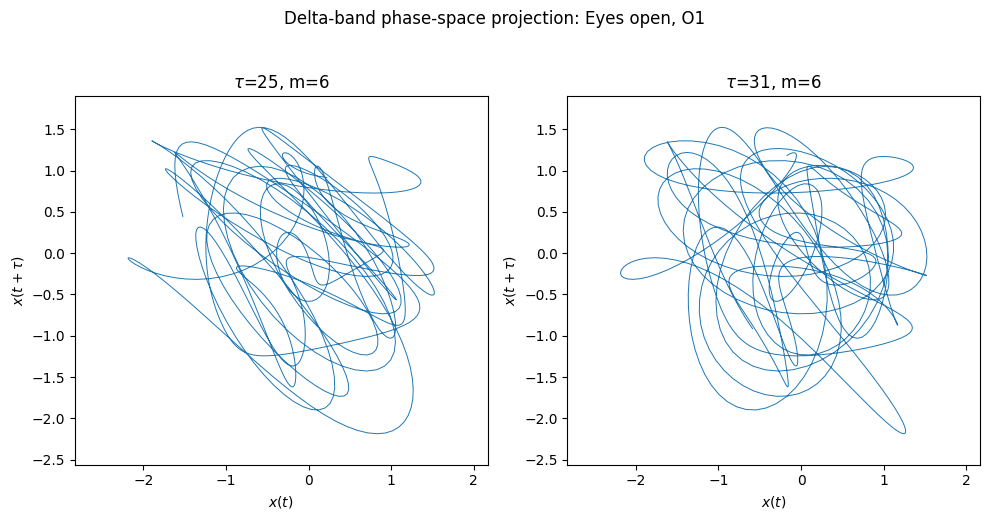

Eyes open, Alpha, τ=25, m=6: embedded=(9635, 6), plotted=(1000, 6)
Eyes open, Alpha, τ=31, m=6: embedded=(9605, 6), plotted=(1000, 6)


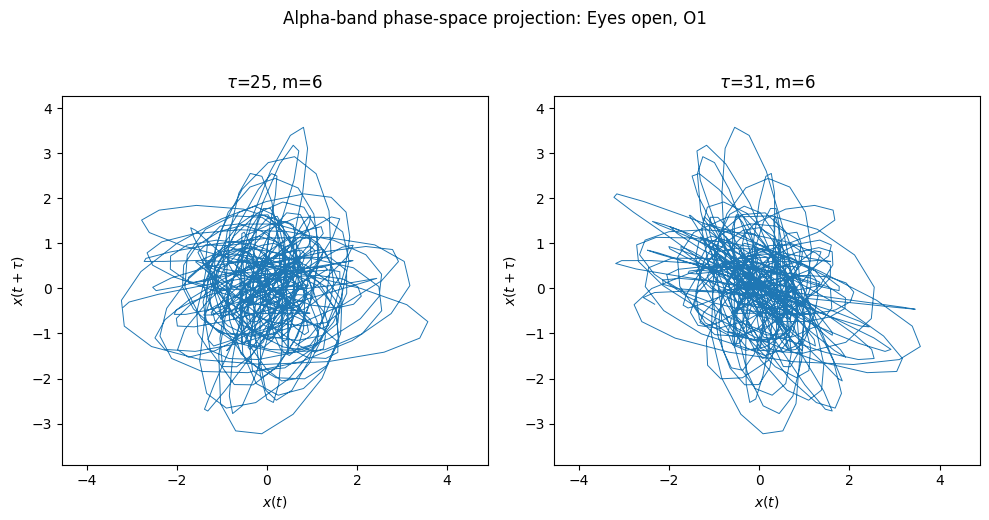

Eyes closed, Alpha, τ=5, m=6: embedded=(9735, 6), plotted=(1000, 6)
Eyes closed, Alpha, τ=8, m=6: embedded=(9720, 6), plotted=(1000, 6)


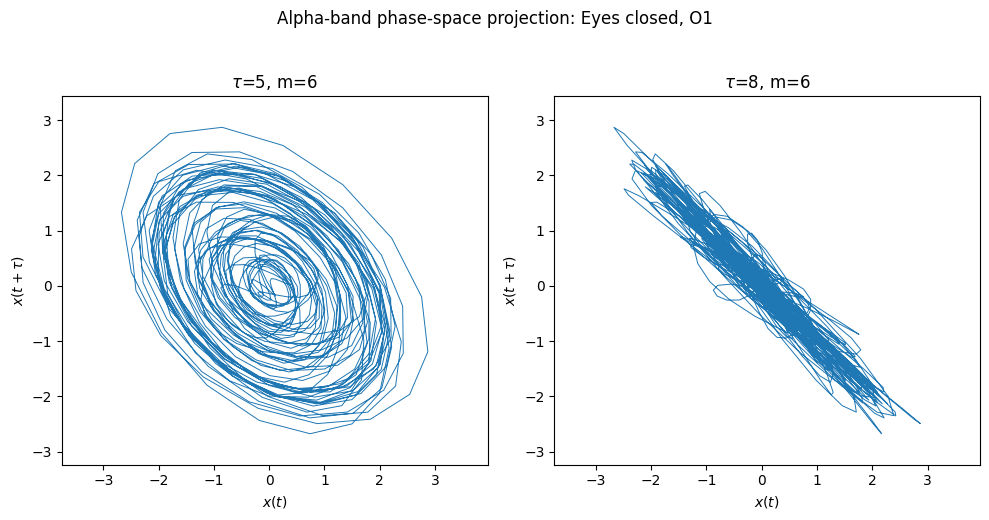

In [37]:
import numpy as np
import matplotlib.pyplot as plt


def plot_band_phase_projection(
    raws,
    condition,
    channel,
    band_name,
    band_range,
    taus,
    m=6,
    n_points=1000,
    segment="middle"
):
    raw = raws[condition]

    # Band-pass filter
    raw_band = raw.copy().filter(
        band_range[0],
        band_range[1],
        fir_design="firwin",
        verbose=False
    )

    # Extract and z-score signal
    x = raw_band.copy().pick([channel]).get_data()[0] * 1e6
    x = (x - np.mean(x)) / np.std(x)

    fig, axes = plt.subplots(1, len(taus), figsize=(5 * len(taus), 5))

    if len(taus) == 1:
        axes = [axes]

    for ax, tau in zip(axes, taus):
        X = delay_embedding(x, m=m, tau=tau)

        n = min(n_points, len(X))

        if segment == "middle":
            start = max(0, len(X) // 2 - n // 2)
        else:
            start = 0

        Xs = X[start:start + n]

        ax.plot(Xs[:, 0], Xs[:, 1], linewidth=0.7)
        ax.set_xlabel(r"$x(t)$")
        ax.set_ylabel(r"$x(t+\tau)$")
        ax.set_title(f"$\\tau$={tau}, m={m}")
        ax.axis("equal")

        print(
            f"{condition}, {band_name}, τ={tau}, m={m}: "
            f"embedded={X.shape}, plotted={Xs.shape}"
        )

    fig.suptitle(
        f"{band_name}-band phase-space projection: {condition}, {channel}",
        y=1.03
    )
    plt.tight_layout()
    plt.show()


analysis_channel = "O1"
m = 6
n_points = 1000

bands = {
    "Delta": (1, 4),
    "Alpha": (8, 13),
}

# Eyes open: delta and alpha
for band_name in ["Delta", "Alpha"]:
    plot_band_phase_projection(
        raws=raws,
        condition="Eyes open",
        channel=analysis_channel,
        band_name=band_name,
        band_range=bands[band_name],
        taus=[25, 31],
        m=m,
        n_points=n_points
    )

# Eyes closed: alpha only
plot_band_phase_projection(
    raws=raws,
    condition="Eyes closed",
    channel=analysis_channel,
    band_name="Alpha",
    band_range=bands["Alpha"],
    taus=[5, 8],
    m=m,
    n_points=n_points
)

### 1.4. Feature extraction

For each channel, we compute a set of features describing the EEG signal from different perspectives:

- **Variance** (time domain)
- **Alpha-band power (8–13 Hz)** (frequency domain)
- **Sample entropy** (signal complexity)
- **Higuchi fractal dimension** (signal complexity)
- **Correlation dimension** (estimated dimensionality of the reconstructed attractor)
- **Largest Lyapunov exponent** (sensitivity to small perturbations in the reconstructed dynamics)

The nonlinear features based on phase-space reconstruction (correlation dimension and Lyapunov exponent) require selecting an embedding delay (**τ**) and embedding dimension (**m**). Since the occipital channels **O1** and **O2** exhibit very similar dynamics and the autocorrelation analysis produced the same candidate delays for both channels, the embedding parameters determined from **O1** were used for both occipital channels. Specifically, we use **τ = 31** for the eyes-open condition and **τ = 8** for the eyes-closed condition, with an embedding dimension of **m = 6**.

In [38]:
import antropy as ant
import nolds

def corr_dim_debug(x, emb_dim=3, n_points=3000):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) > n_points:
        start = max(0, len(x)//2 - n_points//2)
        x = x[start:start+n_points]

    x = (x - np.mean(x)) / np.std(x)

    try:
        return nolds.corr_dim(x, emb_dim=emb_dim)
    except Exception as e:
        print("corr_dim error:", repr(e))
        return np.nan


def lyapunov_debug(x, emb_dim=3, tau=8, n_points=3000):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) > n_points:
        start = max(0, len(x)//2 - n_points//2)
        x = x[start:start+n_points]

    x = (x - np.mean(x)) / np.std(x)

    try:
        return nolds.lyap_r(
            x,
            emb_dim=emb_dim,
            lag=tau,
            min_tsep=tau * emb_dim,
            trajectory_len=10
        )
    except Exception as e:
        print("lyap error:", repr(e))
        return np.nan

def bandpower_mne(raw, channel, fmin, fmax):
    psd = raw.compute_psd(
        method="welch",
        fmin=fmin,
        fmax=fmax,
        picks=[channel],
        verbose=False
    )

    freqs = psd.freqs
    power = psd.get_data()[0]

    mask = (freqs >= fmin) & (freqs <= fmax)

    return np.trapezoid(power[mask], freqs[mask])


def extract_features_from_raw(raw, condition, channels, emb_dim=6, tau=8):
    sfreq = raw.info["sfreq"]
    data = raw.copy().pick(channels).get_data()

    rows = []

    for ch_idx, ch in enumerate(channels):
        x = data[ch_idx]

        features = {
            "variance": np.var(x),
            "alpha_power_8_13": bandpower_mne(raw, ch, 8, 13),
            "sample_entropy": ant.sample_entropy(x),
            "higuchi_fd": ant.higuchi_fd(x),

            "corr_dim": corr_dim_debug(x, emb_dim=emb_dim),
            "lyapunov": lyapunov_debug(x, emb_dim=emb_dim, tau=tau),

            "condition": condition,
            "channel": ch,
            "duration_sec": len(x) / sfreq,
            "tau": tau,
            "emb_dim": emb_dim,
        }

        rows.append(features)

    return rows


rows = []

tau_by_condition = {
    "Eyes open": 31,
    "Eyes closed": 8,
}

for condition, raw in raws.items():
    rows.extend(
        extract_features_from_raw(
            raw,
            condition,
            channels,
            emb_dim=6,
            tau=tau_by_condition.get(condition, 8)
        )
    )

features = pd.DataFrame(rows)
features

,variance,alpha_power_8_13,sample_entropy,higuchi_fd,corr_dim,lyapunov,condition,channel,duration_sec,tau,emb_dim
0,1.852720e-09,2.363723e-10,0.893963,1.528410,2.013899,0.006993,Eyes open,O1,61.0,31,6
1,1.942645e-09,1.982046e-10,0.974553,1.556044,2.267592,0.014972,Eyes open,O2,61.0,31,6
2,5.593117e-09,3.198890e-09,0.799546,1.396523,1.999673,-0.079818,Eyes closed,O1,61.0,8,6
3,5.594374e-09,3.046402e-09,0.863610,1.415545,1.746642,-0.075250,Eyes closed,O2,61.0,8,6


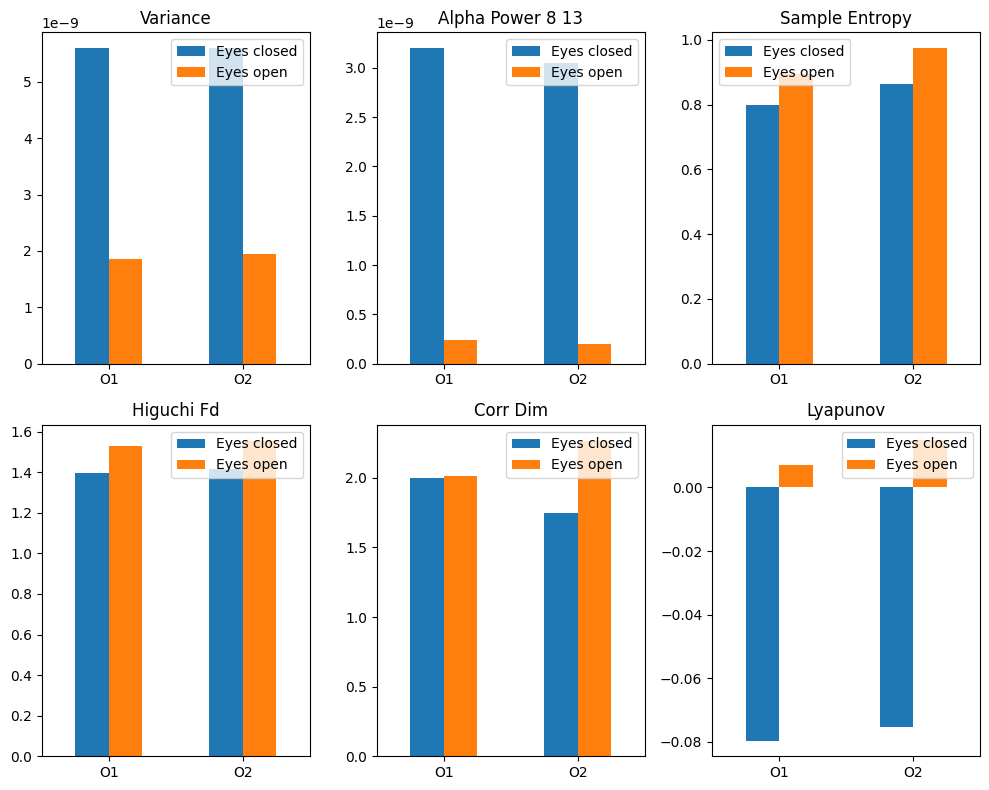

In [39]:
import matplotlib.pyplot as plt

feature_cols = [
    "variance",
    "alpha_power_8_13",
    "sample_entropy",
    "higuchi_fd",
    "corr_dim",
    "lyapunov",
]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

for ax, feat in zip(axes, feature_cols):

    pivot = features.pivot(
        index="channel",
        columns="condition",
        values=feat
    )

    pivot.plot(kind="bar", ax=ax)

    ax.set_title(feat.replace("_", " ").title())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="")

plt.tight_layout()
plt.show()

**Observation:** Not all features are equally sensitive to changes in brain state. In this example, **variance** and **alpha-band power** provide the clearest separation between eyes open and eyes closed, reflecting the strong alpha synchronization that occurs when visual input is removed. The **largest Lyapunov exponent** also differs markedly between the two conditions, indicating changes in the underlying dynamics beyond simple oscillatory power. Meanwhile, **sample entropy**, **Higuchi fractal dimension**, and **correlation dimension** vary less, suggesting that different nonlinear measures capture different aspects of EEG complexity and should be interpreted as complementary rather than interchangeable.

#### **REPEATED FEATURE EXTRACTION WITH CLASS-INDEPENDENT TAU (fixed value)**

In [40]:
rows = []

tau_by_condition = {
    "Eyes open": 8,         #we pick lower tau
    "Eyes closed": 8,
}

for condition, raw in raws.items():
    rows.extend(
        extract_features_from_raw(
            raw,
            condition,
            channels,
            emb_dim=6,
            tau=tau_by_condition.get(condition, 8)
        )
    )

features = pd.DataFrame(rows)
features

,variance,alpha_power_8_13,sample_entropy,higuchi_fd,corr_dim,lyapunov,condition,channel,duration_sec,tau,emb_dim
0,1.852720e-09,2.363723e-10,0.893963,1.528410,2.092282,-0.104845,Eyes open,O1,61.0,8,6
1,1.942645e-09,1.982046e-10,0.974553,1.556044,2.221117,-0.046333,Eyes open,O2,61.0,8,6
2,5.593117e-09,3.198890e-09,0.799546,1.396523,1.999673,-0.079818,Eyes closed,O1,61.0,8,6
3,5.594374e-09,3.046402e-09,0.863610,1.415545,1.665435,-0.109933,Eyes closed,O2,61.0,8,6


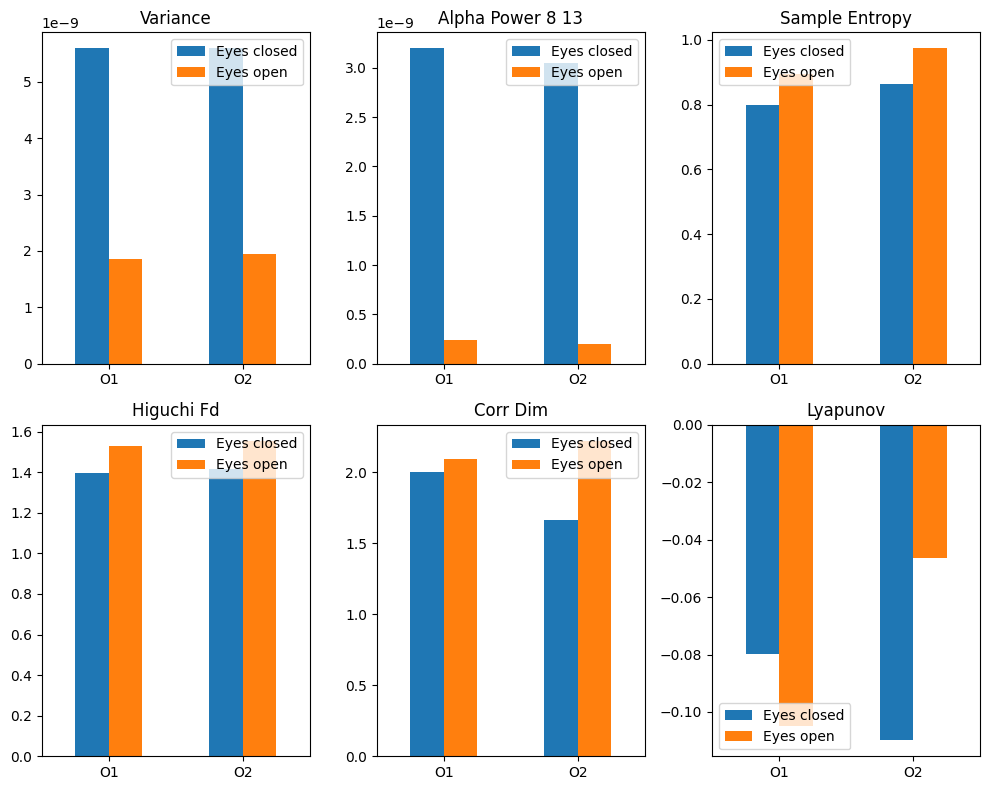

In [41]:
import matplotlib.pyplot as plt

feature_cols = [
    "variance",
    "alpha_power_8_13",
    "sample_entropy",
    "higuchi_fd",
    "corr_dim",
    "lyapunov",
]

fig, axes = plt.subplots(2, 3, figsize=(10, 8))
axes = axes.flatten()

for ax, feat in zip(axes, feature_cols):

    pivot = features.pivot(
        index="channel",
        columns="condition",
        values=feat
    )

    pivot.plot(kind="bar", ax=ax)

    ax.set_title(feat.replace("_", " ").title())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="")

plt.tight_layout()
plt.show()

*Notice how Lyapunov is not as discriminative as before. Can you guess why?*

## 2. Motor imagery

In this part, we analyze motor imagery EEG from one subject during imagined movement tasks. We use **subject 1, run 6**, which contains two motor imagery classes:

- **T1** – imagined both hands
- **T2** – imagined both feet

The analysis focuses on channels **C3**, **Cz**, and **C4**, which are located over the sensorimotor cortex and are commonly used in motor imagery BCI analysis. Also, analysis is performed on **epochs**, where each epoch starts at its corresponding **event marker** (motor imagery cue):

| Step | What is shown |
|:-------------------|:--------------|
| Raw EEG | C3/Cz/C4 recording with event markers and example epochs |
| Stationarity | Windowed mean and variance over time |
| PSD | Welch PSD, 1–40 Hz |
| Phase space | Autocorrelation (τ selection), false nearest neighbors (m selection), 2D/3D reconstruction, band-specific phase spaces |
| Feature extraction | Variance, alpha power (8–13 Hz), sample entropy, Higuchi fractal dimension, correlation dimension, largest Lyapunov exponent |

### 2.1. Raw EEG and event markers

We first inspect the continuous EEG recording together with the event annotations. The vertical dashed lines indicate the event markers: **T0** – rest/baseline, **T1** – imagined both hands, **T2** – imagined both feet.

In [11]:
subject = 1
run = 6
channels = ["C3", "Cz", "C4"]

class_names = {
    "T1": "Imagined both hands",
    "T2": "Imagined both feet",
}


def load_motor_imagery_raw(subject, run, l_freq=1.0, h_freq=40.0):
    file = eegbci.load_data(subject, [run])[0]

    raw = read_raw_edf(file, preload=True)

    eegbci.standardize(raw)

    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage)

    raw.pick("eeg")
    raw.filter(l_freq, h_freq, fir_design="firwin")

    return raw


raw_mi = load_motor_imagery_raw(subject, run)

print(raw_mi)
print(raw_mi.annotations)

events, event_id = mne.events_from_annotations(raw_mi)

print(event_id)
print("Number of events:", len(events))

pd.Series(raw_mi.annotations.description).value_counts()

Extracting EDF parameters from C:\Users\Nikolina\mne_data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)

<RawEDF | S001R06.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Annotations | 30 segments: T0 (15), T1 (7), T2 (8)>
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
{np.s

T0    15
T2     8
T1     7
Name: count, dtype: int64

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


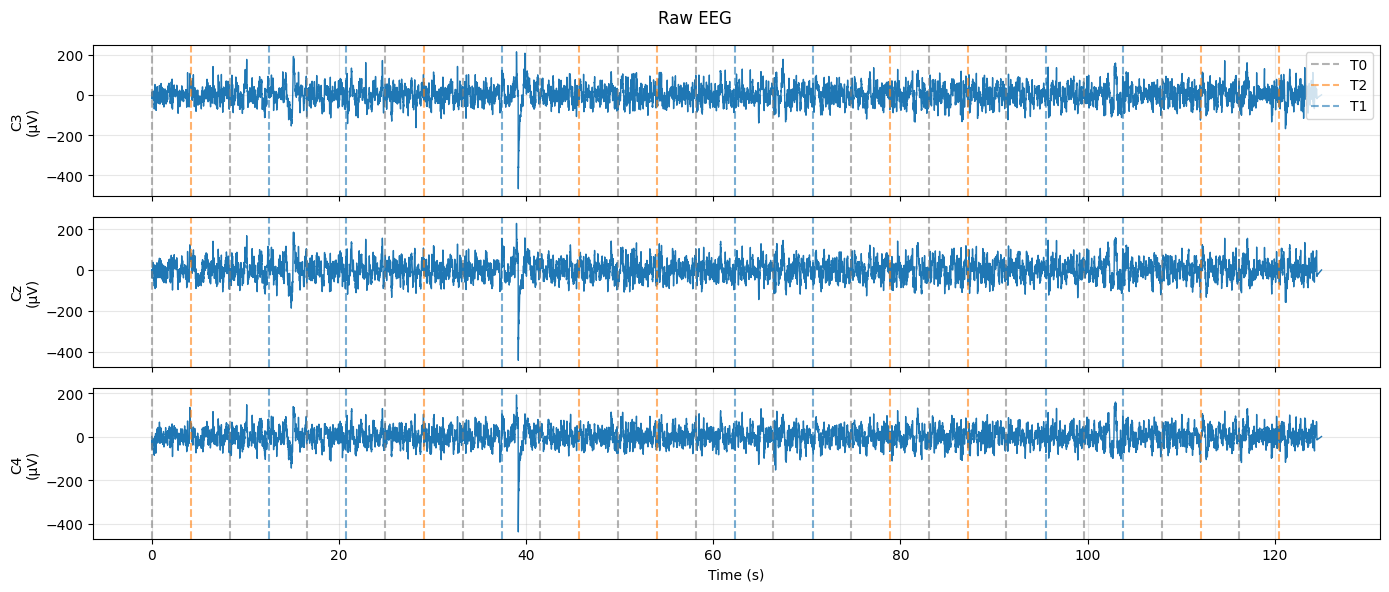

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


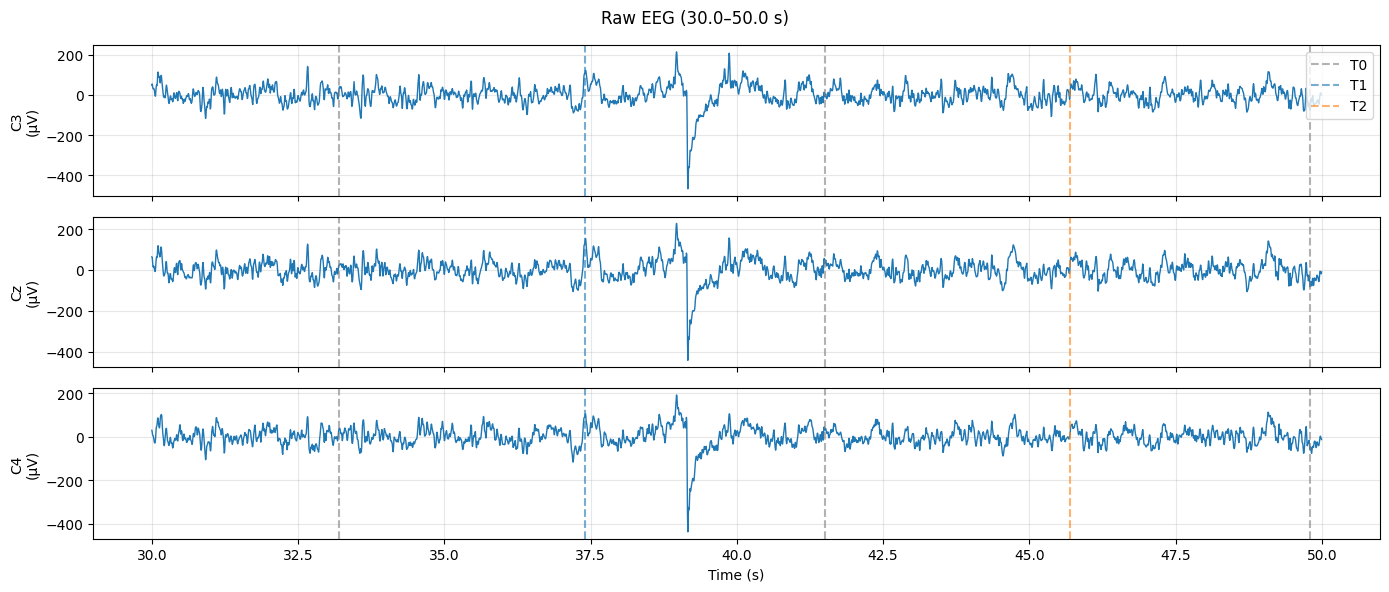

In [12]:
def plot_raw_segment(raw, channels, start_sec=0, duration_sec=None):

    sfreq = raw.info["sfreq"]

    start = int(start_sec * sfreq)

    if duration_sec is None:
        stop = raw.n_times
    else:
        stop = int((start_sec + duration_sec) * sfreq)

    raw_sel = raw.copy().pick(channels)

    data, times = raw_sel.get_data(
        start=start,
        stop=stop,
        return_times=True
    )

    fig, axes = plt.subplots(
        len(channels),
        1,
        figsize=(14, 6),
        sharex=True
    )

    if len(channels) == 1:
        axes = [axes]

    for i, ch in enumerate(channels):
        axes[i].plot(times, data[i] * 1e6, linewidth=1)
        axes[i].set_ylabel(f"{ch}\n(µV)")
        axes[i].grid(alpha=0.3)

    # Plot event markers
    events, event_id = mne.events_from_annotations(raw)

    colors = {
        event_id["T0"]: "gray",
        event_id["T1"]: "tab:blue",
        event_id["T2"]: "tab:orange",
    }

    labels = {
        event_id["T0"]: "T0",
        event_id["T1"]: "T1",
        event_id["T2"]: "T2",
    }

    plotted = set()

    for sample, _, code in events:
        t = sample / sfreq

        if t < start_sec:
            continue
        if duration_sec is not None and t > start_sec + duration_sec:
            continue

        for ax in axes:
            ax.axvline(
                t,
                color=colors[code],
                linestyle="--",
                alpha=0.6,
                label=labels[code] if code not in plotted else None
            )

        plotted.add(code)

    axes[-1].set_xlabel("Time (s)")
    axes[0].legend(loc="upper right")

    title = "Raw EEG"
    if duration_sec is not None:
        title += f" ({start_sec:.1f}–{start_sec+duration_sec:.1f} s)"

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Entire recording
plot_raw_segment(raw_mi, channels)

# segment
plot_raw_segment(raw_mi, channels, start_sec=30, duration_sec=20)

### 2.2 Epoch creation
- inspect time between events
- create epochs so that each epoch starts from its own event timestamp

In [13]:
np.diff(events[:,0]) / raw.info["sfreq"]

array([4.2, 4.1, 4.2, 4.1, 4.2, 4.1, 4.2, 4.1, 4.2, 4.1, 4.2, 4.1, 4.2,
       4.1, 4.2, 4.1, 4.2, 4.1, 4.2, 4.1, 4.2, 4.1, 4.2, 4.1, 4.2, 4.1,
       4.2, 4.1, 4.2])

In [14]:
# Keep only motor imagery events
mi_event_id = {
    "T1": event_id["T1"],
    "T2": event_id["T2"],
}

tmin = 0.0
tmax = 4.0

epochs_mi = mne.Epochs(
    raw_mi,
    events,
    event_id=mi_event_id,
    tmin=tmin,
    tmax=tmax,
    picks=channels,
    baseline=None,
    preload=True,
    verbose=False
)

print(epochs_mi)
print(epochs_mi.event_id)

<Epochs | 15 events (all good), 0 – 4 s (baseline off), ~257 KiB, data loaded,
 'T1': 7
 'T2': 8>
{'T1': 2, 'T2': 3}


In [15]:
pd.Series(epochs_mi.events[:, 2]).map({
    event_id["T1"]: class_names["T1"],
    event_id["T2"]: class_names["T2"],
}).value_counts()

Imagined both feet     8
Imagined both hands    7
Name: count, dtype: int64

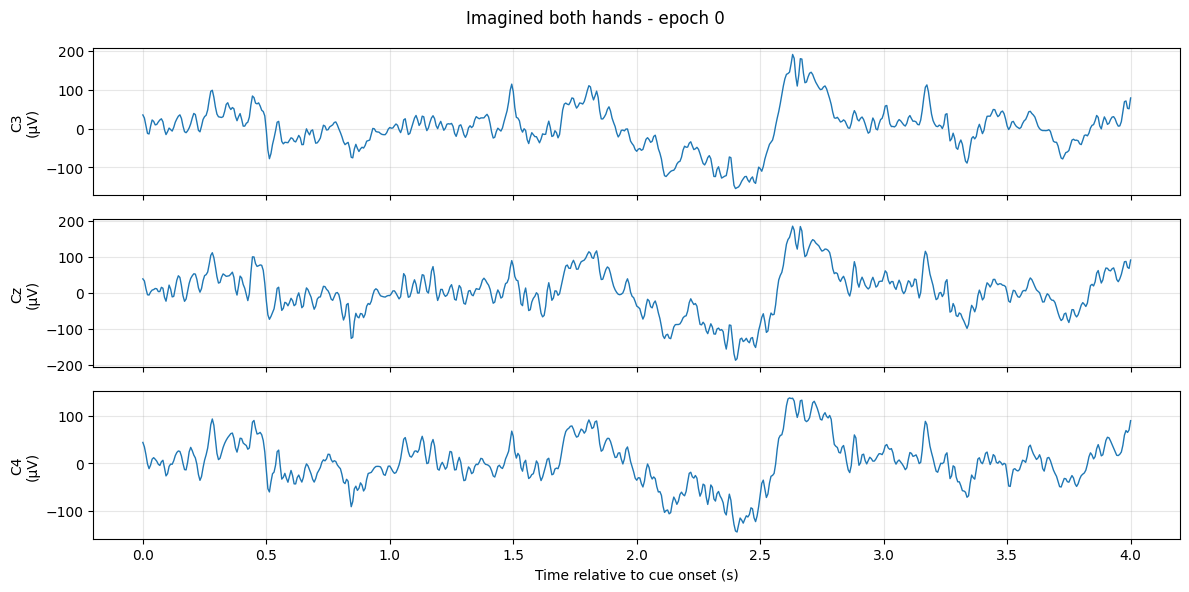

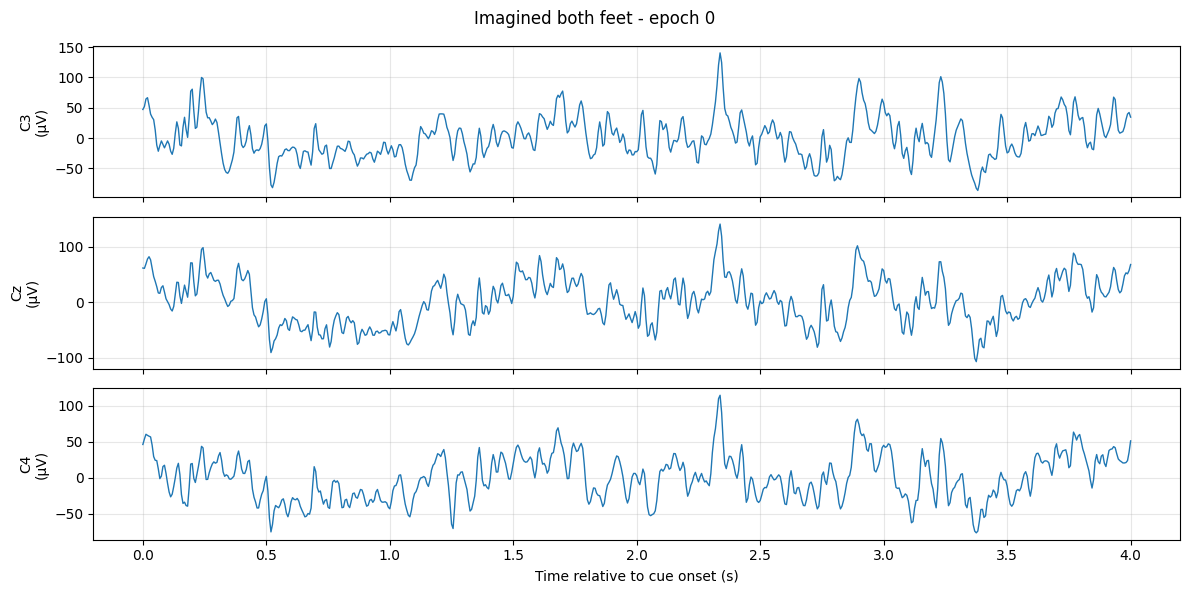

In [16]:
def plot_mi_epoch(epochs, condition, epoch_idx=0):
    ep = epochs[condition][epoch_idx]
    data = ep.get_data()[0] * 1e6
    times = ep.times

    fig, axes = plt.subplots(
        len(channels),
        1,
        figsize=(12, 6),
        sharex=True
    )

    for i, ch in enumerate(channels):
        axes[i].plot(times, data[i], linewidth=1)
        axes[i].set_ylabel(f"{ch}\n(µV)")
        axes[i].grid(alpha=0.3)

    axes[-1].set_xlabel("Time relative to cue onset (s)")
    plt.suptitle(f"{class_names[condition]} - epoch {epoch_idx}")
    plt.tight_layout()
    plt.show()


plot_mi_epoch(epochs_mi, "T1", epoch_idx=0)
plot_mi_epoch(epochs_mi, "T2", epoch_idx=0)

### 2.3 PSD

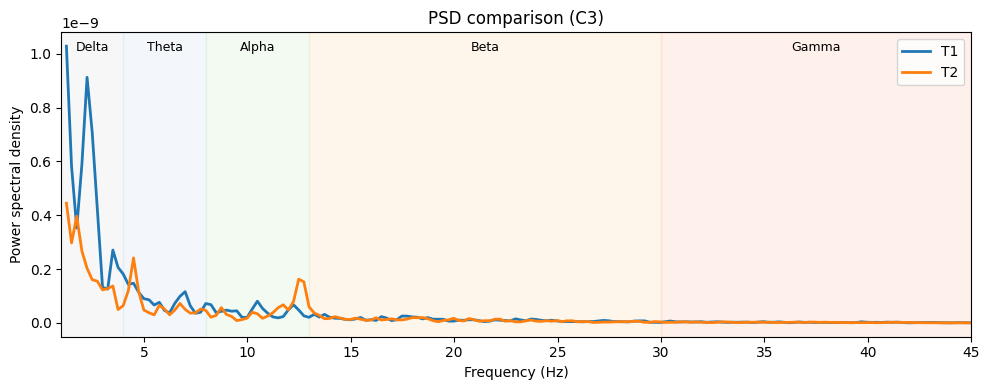

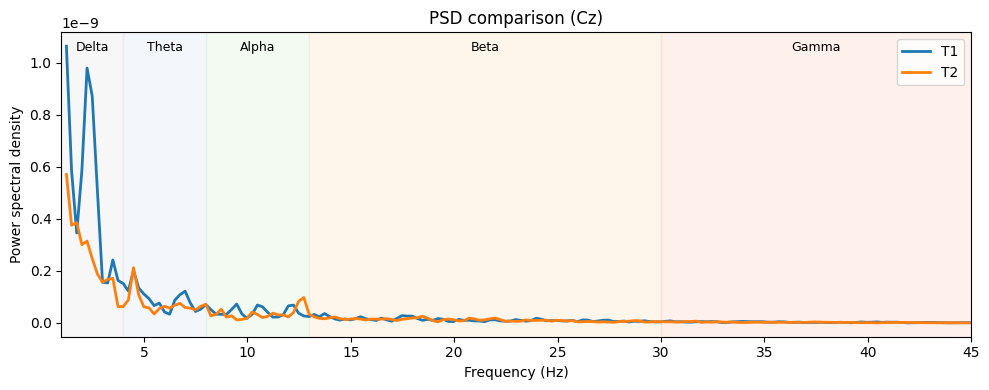

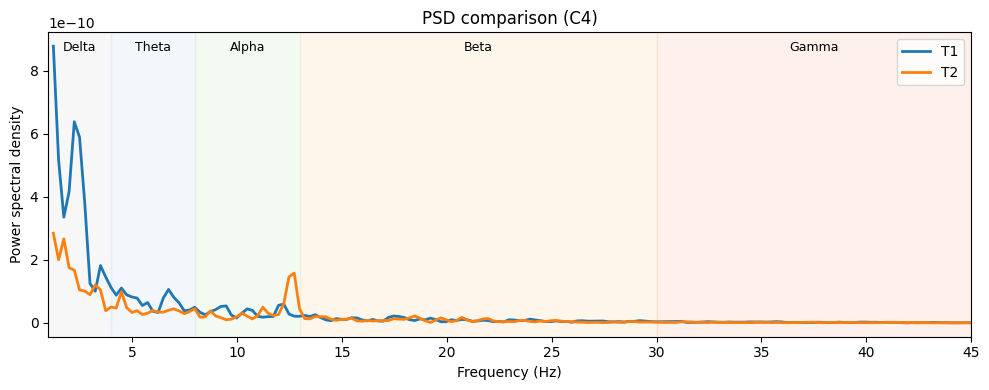

In [17]:
def plot_epoch_psd_by_condition(epochs, channels, fmin=1, fmax=45):
    conditions = list(epochs.event_id.keys())

    bands = {
        "Delta": (1, 4),
        "Theta": (4, 8),
        "Alpha": (8, 13),
        "Beta": (13, 30),
        "Gamma": (30, 45),
    }

    band_colors = {
        "Delta": "#d9d9d9",
        "Theta": "#c6dbef",
        "Alpha": "#c7e9c0",
        "Beta": "#fdd49e",
        "Gamma": "#fcbba1",
    }

    for ch in channels:

        plt.figure(figsize=(10, 4))

        # Plot PSDs
        for condition in conditions:

            psd = epochs[condition].compute_psd(
                method="welch",
                fmin=fmin,
                fmax=fmax,
                picks=[ch],
                verbose=False,
            )

            freqs = psd.freqs
            power = psd.get_data().mean(axis=0)[0]

            plt.plot(freqs, power, linewidth=2, label=condition)

        # Shade EEG bands
        ymin, ymax = plt.ylim()

        for name, (f1, f2) in bands.items():

            plt.axvspan(
                f1,
                f2,
                color=band_colors[name],
                alpha=0.20,
            )

            plt.text(
                (f1 + f2) / 2,
                ymax * 0.97,
                name,
                ha="center",
                va="top",
                fontsize=9,
            )

        plt.title(f"PSD comparison ({ch})")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power spectral density")
        plt.xlim(fmin, fmax)
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_epoch_psd_by_condition(epochs_mi, channels)


### 2.4. Stationarity & phase space

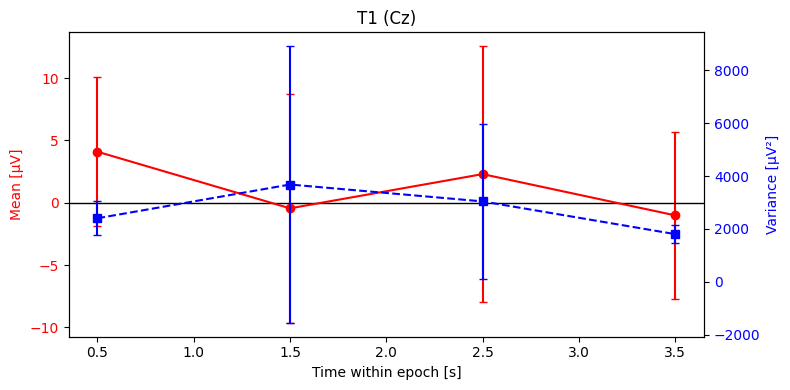

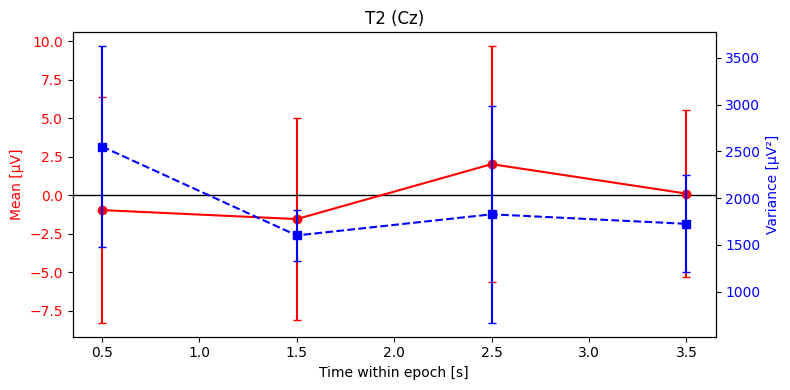

In [18]:
analysis_channel = "Cz"
window_sec = 1.0

def window_stats_from_epochs(epochs, channel, window_sec=1.0):
    sfreq = epochs.info["sfreq"]
    ch_idx = epochs.ch_names.index(channel)
    window_len = int(window_sec * sfreq)

    rows = []

    for condition in epochs.event_id.keys():
        data = epochs[condition].get_data(copy=True)  # n_epochs x n_channels x n_times

        for ep_idx, ep in enumerate(data):
            x = ep[ch_idx] * 1e6  # µV
            n_windows = len(x) // window_len

            for w in range(n_windows):
                start = w * window_len
                stop = start + window_len
                segment = x[start:stop]

                rows.append({
                    "condition": condition,
                    "epoch": ep_idx,
                    "channel": channel,
                    "window": w,
                    "start_sec": start / sfreq,
                    "end_sec": stop / sfreq,
                    "mean": np.mean(segment),
                    "variance": np.var(segment),
                })

    return pd.DataFrame(rows)


stationarity_epochs = window_stats_from_epochs(
    epochs_mi,
    channel=analysis_channel,
    window_sec=window_sec
)

summary = (
    stationarity_epochs
    .groupby(["condition", "window"])
    .agg(
        start_sec=("start_sec", "mean"),
        end_sec=("end_sec", "mean"),
        mean=("mean", "mean"),
        mean_sd=("mean", "std"),
        variance=("variance", "mean"),
        variance_sd=("variance", "std"),
    )
    .reset_index()
)

def plot_epoch_stationarity_summary(stationarity_epochs, channel):

    for condition in stationarity_epochs["condition"].unique():

        df = (
            stationarity_epochs[
                stationarity_epochs["condition"] == condition
            ]
            .groupby("window")
            .agg(
                start_sec=("start_sec", "mean"),
                end_sec=("end_sec", "mean"),
                mean=("mean", "mean"),
                mean_sd=("mean", "std"),
                variance=("variance", "mean"),
                variance_sd=("variance", "std"),
            )
            .reset_index()
        )

        centers = (df["start_sec"] + df["end_sec"]) / 2

        fig, ax1 = plt.subplots(figsize=(8, 4))

        ax1.errorbar(
            centers,
            df["mean"],
            yerr=df["mean_sd"],
            fmt="o-",
            color="red",
            capsize=3,
            label="Window mean"
        )

        ax1.axhline(0, color="black", linewidth=1)
        ax1.set_xlabel("Time within epoch [s]")
        ax1.set_ylabel("Mean [µV]", color="red")
        ax1.tick_params(axis="y", labelcolor="red")

        ax2 = ax1.twinx()

        ax2.errorbar(
            centers,
            df["variance"],
            yerr=df["variance_sd"],
            fmt="s--",
            color="blue",
            capsize=3,
            label="Window variance"
        )

        ax2.set_ylabel("Variance [µV²]", color="blue")
        ax2.tick_params(axis="y", labelcolor="blue")

        plt.title(f"{condition} ({channel})")
        plt.tight_layout()
        plt.show()


plot_epoch_stationarity_summary(stationarity_epochs, analysis_channel)




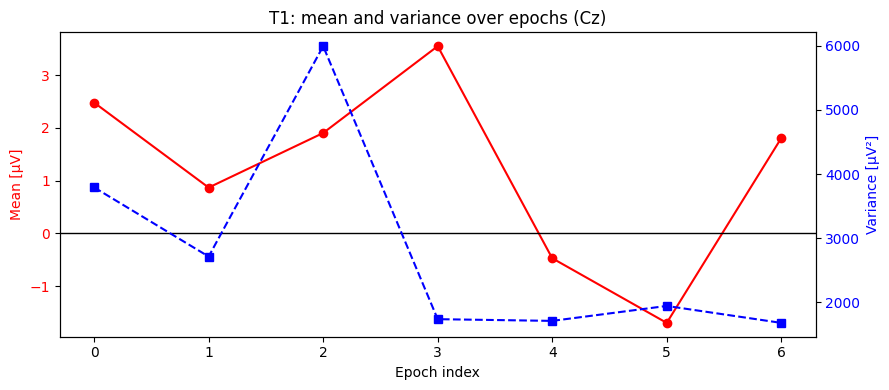

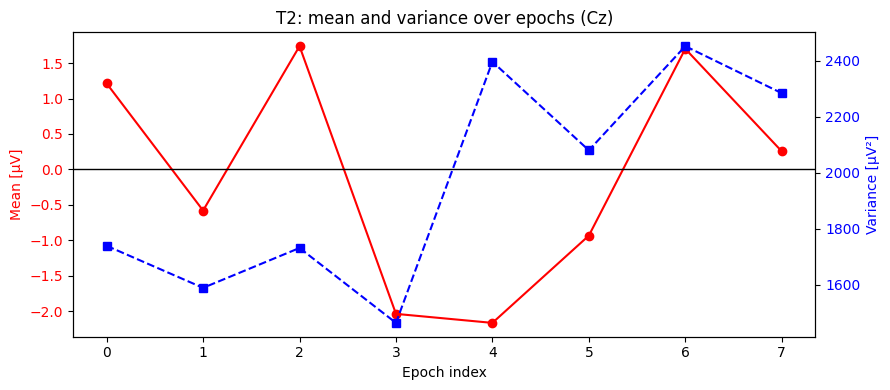

In [19]:
analysis_channel = "Cz"

def stats_per_epoch(epochs, channel):
    sfreq = epochs.info["sfreq"]
    ch_idx = epochs.ch_names.index(channel)

    rows = []

    for condition in epochs.event_id.keys():
        data = epochs[condition].get_data(copy=True)

        for ep_idx, ep in enumerate(data):
            x = ep[ch_idx] * 1e6  # µV

            rows.append({
                "condition": condition,
                "epoch": ep_idx,
                "channel": channel,
                "mean": np.mean(x),
                "variance": np.var(x),
            })

    return pd.DataFrame(rows)


stationarity_epochs_time = stats_per_epoch(
    epochs_mi,
    channel=analysis_channel
)

def plot_epoch_mean_variance_over_trials(df, channel):

    for condition in df["condition"].unique():
        d = df[df["condition"] == condition].copy()

        fig, ax1 = plt.subplots(figsize=(9, 4))

        ax1.plot(
            d["epoch"],
            d["mean"],
            marker="o",
            color="red",
            label="Epoch mean"
        )

        ax1.axhline(0, color="black", linewidth=1)
        ax1.set_xlabel("Epoch index")
        ax1.set_ylabel("Mean [µV]", color="red")
        ax1.tick_params(axis="y", labelcolor="red")

        ax2 = ax1.twinx()

        ax2.plot(
            d["epoch"],
            d["variance"],
            marker="s",
            linestyle="--",
            color="blue",
            label="Epoch variance"
        )

        ax2.set_ylabel("Variance [µV²]", color="blue")
        ax2.tick_params(axis="y", labelcolor="blue")

        plt.title(f"{condition}: mean and variance over epochs ({channel})")
        plt.tight_layout()
        plt.show()


plot_epoch_mean_variance_over_trials(
    stationarity_epochs_time,
    analysis_channel
)



**Observation:** Stationarity depends on the scale of observation. Within a single motor imagery epoch, the windowed mean and variance remain relatively stable, suggesting that each epoch can be treated as approximately stationary. However, when the epochs are viewed sequentially, their overall statistics change from trial to trial, indicating that the complete recording is not stationary. This motivates the common BCI practice of performing feature extraction on individual epochs rather than on the entire continuous recording.

In [20]:
analysis_channels = ["C3", "Cz", "C4"]
max_lag_sec = 1.0

acf_results_mi = {}

for analysis_channel in analysis_channels:
    print("=" * 40)
    print(analysis_channel)
    print("=" * 40)

    acf_results_mi[analysis_channel] = {}

    for condition in ["T1", "T2"]:
        sfreq = epochs_mi.info["sfreq"]

        data = epochs_mi[condition].copy().pick([analysis_channel]).get_data()
        # shape: n_epochs x 1 x n_times

        max_lag = int(max_lag_sec * sfreq)

        acfs = []

        for ep in data:
            x = ep[0] * 1e6
            acf = autocorrelation(x, max_lag)
            acfs.append(acf)

        acfs = np.array(acfs)
        mean_acf = acfs.mean(axis=0)

        tau_min = first_local_minimum(mean_acf)
        tau_zero = first_zero_crossing(mean_acf)

        acf_results_mi[analysis_channel][condition] = {
            "acf": mean_acf,
            "all_acfs": acfs,
            "tau_first_min": tau_min,
            "tau_first_zero": tau_zero,
            "sfreq": sfreq,
            "label": class_names[condition],
        }

        print(class_names[condition])

        if tau_min is not None:
            print(f"First local minimum: τ = {tau_min} samples ({tau_min/sfreq:.3f} s)")
        else:
            print("First local minimum: not found")

        if tau_zero is not None:
            print(f"First zero crossing: τ = {tau_zero} samples ({tau_zero/sfreq:.3f} s)")
        else:
            print("First zero crossing: not found")

        print()

C3
Imagined both hands
First local minimum: τ = 34 samples (0.212 s)
First zero crossing: τ = 28 samples (0.175 s)

Imagined both feet
First local minimum: τ = 10 samples (0.062 s)
First zero crossing: τ = 20 samples (0.125 s)

Cz
Imagined both hands
First local minimum: τ = 45 samples (0.281 s)
First zero crossing: τ = 27 samples (0.169 s)

Imagined both feet
First local minimum: τ = 33 samples (0.206 s)
First zero crossing: τ = 27 samples (0.169 s)

C4
Imagined both hands
First local minimum: τ = 46 samples (0.287 s)
First zero crossing: τ = 29 samples (0.181 s)

Imagined both feet
First local minimum: τ = 10 samples (0.062 s)
First zero crossing: τ = 28 samples (0.175 s)



Imagined both hands, C3, τ=28: suggested m = 5
Imagined both hands, C3, τ=34: suggested m = 5


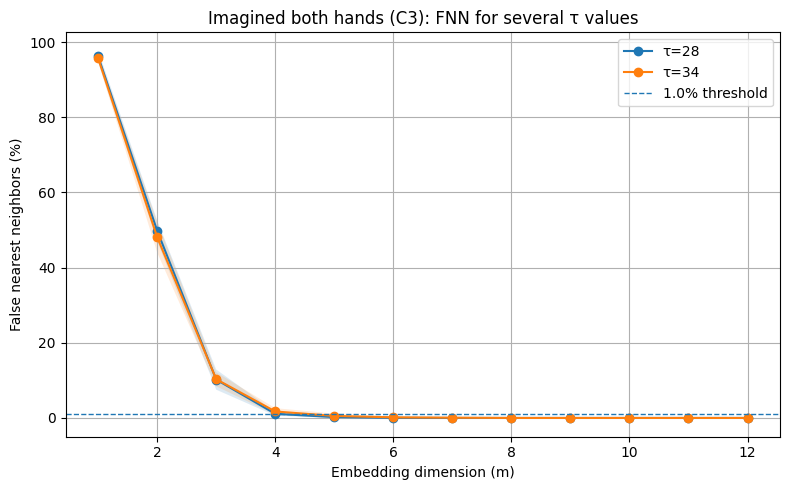

Imagined both hands, Cz, τ=27: suggested m = 5
Imagined both hands, Cz, τ=45: suggested m = 5


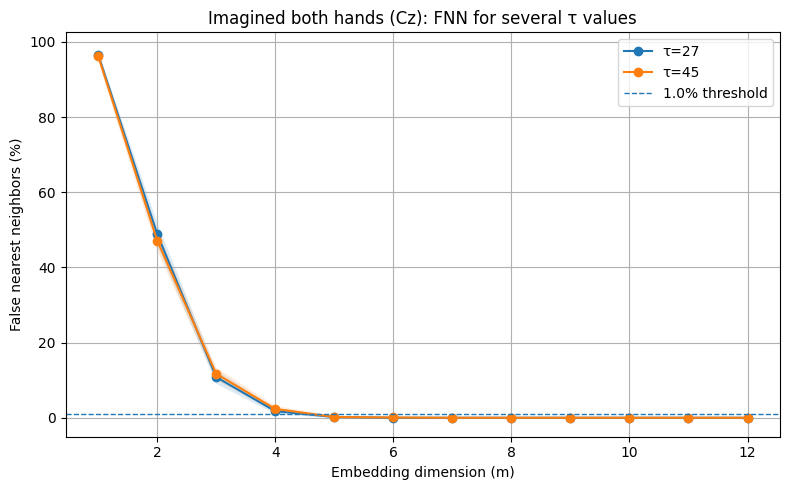

Imagined both hands, C4, τ=29: suggested m = 5
Imagined both hands, C4, τ=46: suggested m = 5


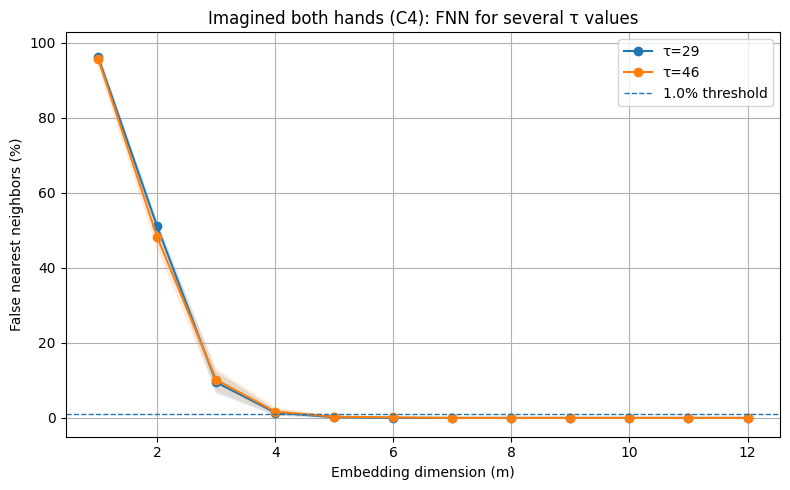

Imagined both feet, C3, τ=10: suggested m = 5
Imagined both feet, C3, τ=20: suggested m = 5


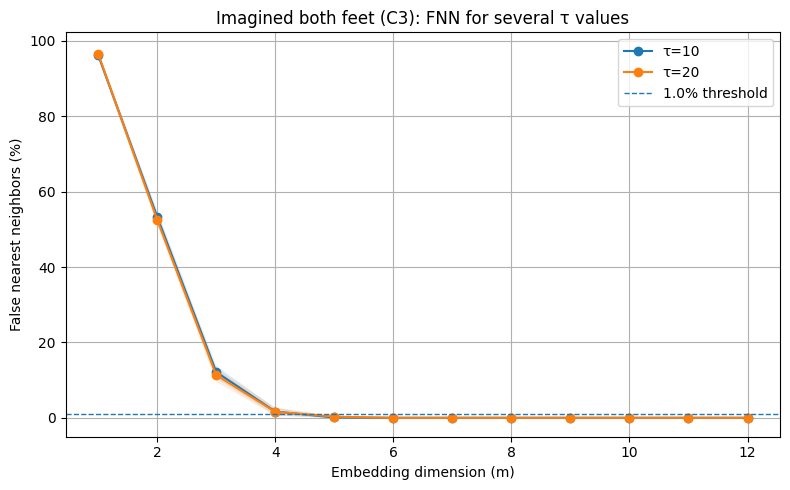

Imagined both feet, Cz, τ=27: suggested m = 5
Imagined both feet, Cz, τ=33: suggested m = 4


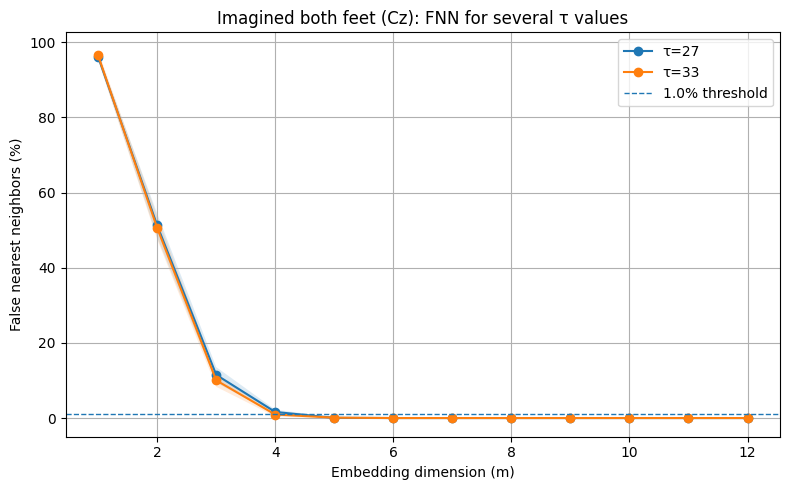

Imagined both feet, C4, τ=10: suggested m = 5
Imagined both feet, C4, τ=28: suggested m = 5


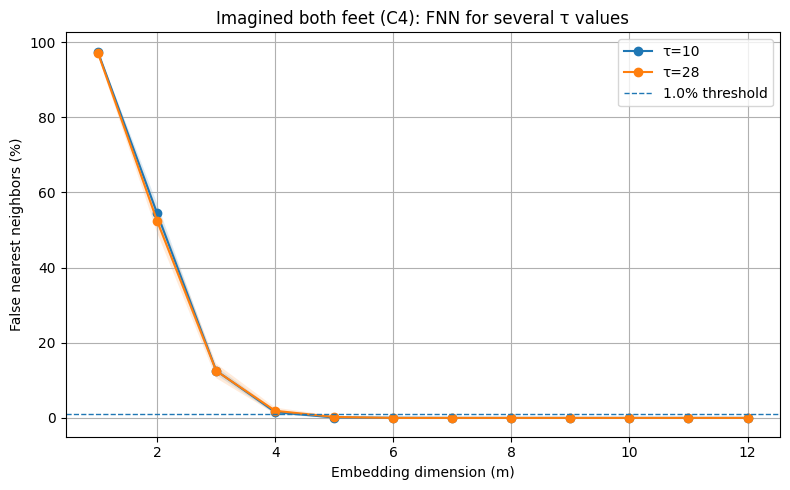

In [21]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt


def delay_embedding(x, m, tau):
    N = len(x) - (m - 1) * tau
    if N <= 0:
        raise ValueError("Time series too short for requested embedding.")

    return np.column_stack(
        [x[i * tau : i * tau + N] for i in range(m)]
    )


def false_nearest_neighbors(x, tau, max_dim=15, rtol=10):
    fnn_percent = []

    for m in range(1, max_dim + 1):
        Xm = delay_embedding(x, m, tau)
        Xm1 = delay_embedding(x, m + 1, tau)

        N = min(len(Xm), len(Xm1))
        Xm = Xm[:N]
        Xm1 = Xm1[:N]

        nbrs = NearestNeighbors(n_neighbors=2).fit(Xm)
        distances, indices = nbrs.kneighbors(Xm)

        false = 0

        for i in range(N):
            nn = indices[i, 1]

            dist_m = distances[i, 1]
            if dist_m == 0:
                continue

            dist_m1 = np.linalg.norm(Xm1[i] - Xm1[nn])

            if dist_m1 / dist_m > rtol:
                false += 1

        fnn_percent.append(100 * false / N)

    return np.array(fnn_percent)


def plot_fnn_for_mi_condition(
    epochs,
    condition,
    channel,
    taus,
    class_names,
    max_dim=12,
    threshold=1.0
):
    data = epochs[condition].copy().pick([channel]).get_data()
    # shape: n_epochs x 1 x n_times

    plt.figure(figsize=(8, 5))

    results = {}

    for tau in taus:
        fnns = []

        for ep in data:
            x = ep[0] * 1e6
            x = (x - np.mean(x)) / np.std(x)

            try:
                fnn = false_nearest_neighbors(
                    x,
                    tau=tau,
                    max_dim=max_dim
                )
                fnns.append(fnn)
            except ValueError:
                pass

        fnns = np.array(fnns)
        mean_fnn = fnns.mean(axis=0)
        std_fnn = fnns.std(axis=0)

        results[tau] = {
            "mean": mean_fnn,
            "std": std_fnn,
            "all": fnns,
        }

        dims = np.arange(1, max_dim + 1)

        plt.plot(
            dims,
            mean_fnn,
            "o-",
            label=f"τ={tau}"
        )

        plt.fill_between(
            dims,
            mean_fnn - std_fnn,
            mean_fnn + std_fnn,
            alpha=0.15
        )

        below = np.where(mean_fnn < threshold)[0]

        if len(below):
            m_opt = below[0] + 1
            print(f"{class_names[condition]}, {channel}, τ={tau}: suggested m = {m_opt}")
        else:
            print(f"{class_names[condition]}, {channel}, τ={tau}: no m below {threshold}%")

    plt.axhline(
        threshold,
        linestyle="--",
        linewidth=1,
        label=f"{threshold}% threshold"
    )

    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False nearest neighbors (%)")
    plt.title(f"{class_names[condition]} ({channel}): FNN for several τ values")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results

analysis_channels = ["C3", "Cz", "C4"]
max_dim = 12
threshold = 1.0

tau_sets_mi = {
    "T1": {
        "C3": [28, 34],  # zero crossing, first local minimum
        "Cz": [27, 45],
        "C4": [29, 46],
    },
    "T2": {
        "C3": [10, 20],  # first local minimum, zero crossing
        "Cz": [27, 33],
        "C4": [10, 28],
    },
}

fnn_results_mi = {}

for condition, channel_taus in tau_sets_mi.items():
    fnn_results_mi[condition] = {}

    for channel, taus in channel_taus.items():
        fnn_results_mi[condition][channel] = plot_fnn_for_mi_condition(
            epochs=epochs_mi,
            condition=condition,
            channel=channel,
            taus=taus,
            class_names=class_names,
            max_dim=max_dim,
            threshold=threshold
        )

In [22]:
#final param sets
m_mi = 5

embedding_params_mi = {
    "T1": {
        "C3": {"tau": 28, "m": m_mi},
        "Cz": {"tau": 27, "m": m_mi},
        "C4": {"tau": 29, "m": m_mi},
    },
    "T2": {
        "C3": {"tau": 10, "m": m_mi},
        "Cz": {"tau": 27, "m": m_mi},
        "C4": {"tau": 10, "m": m_mi},
    },
}

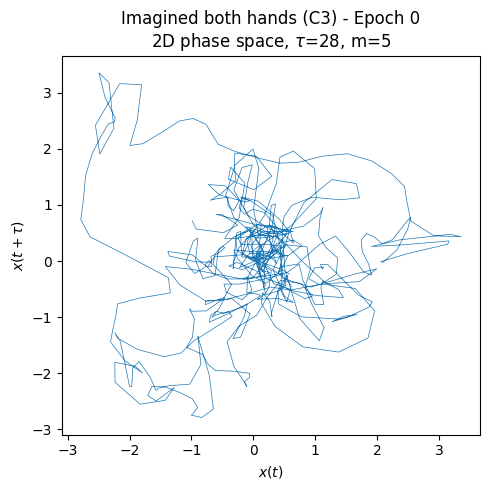

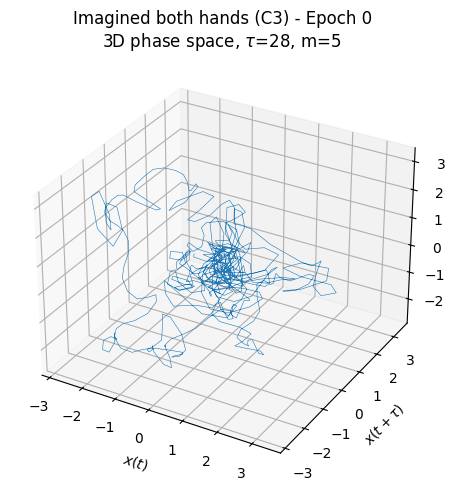

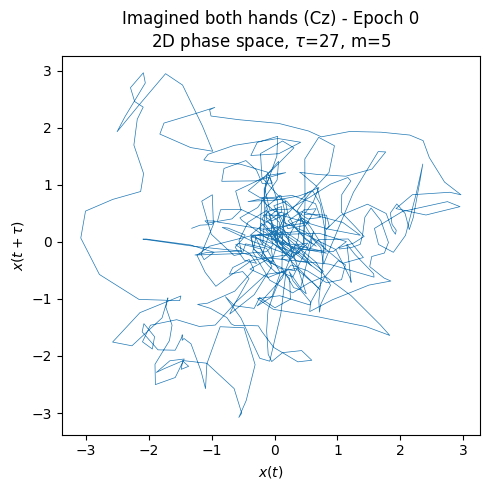

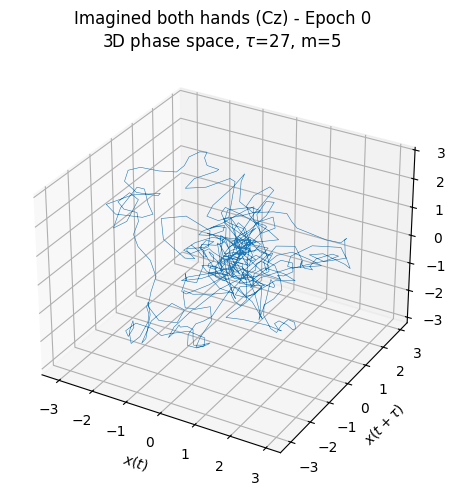

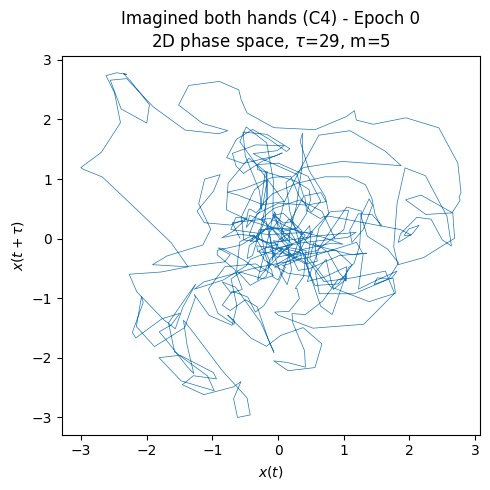

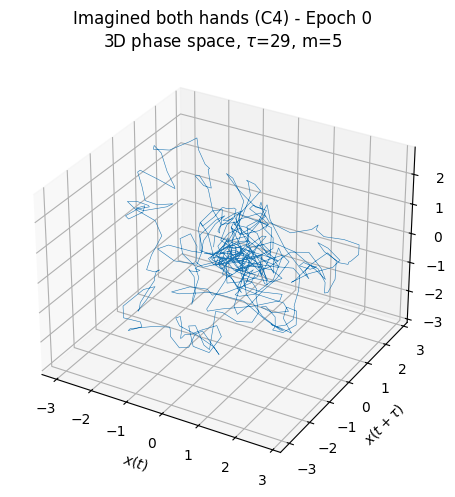

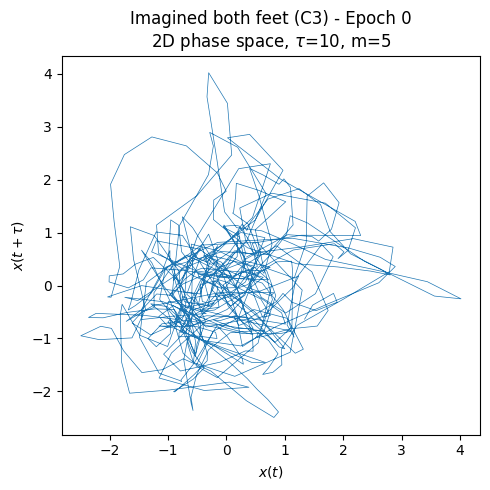

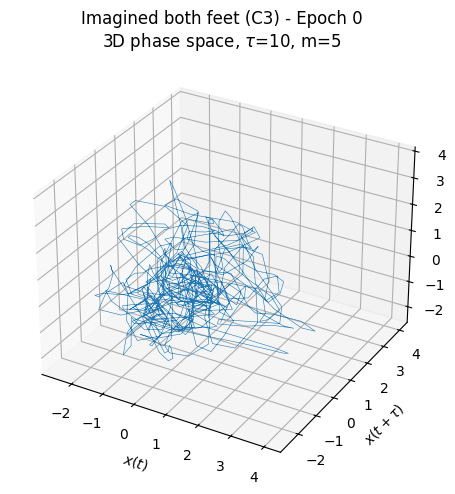

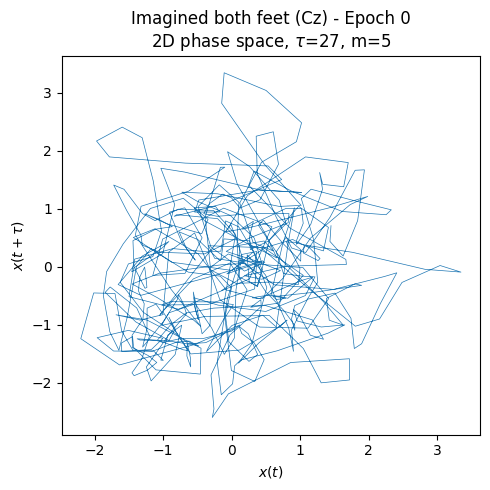

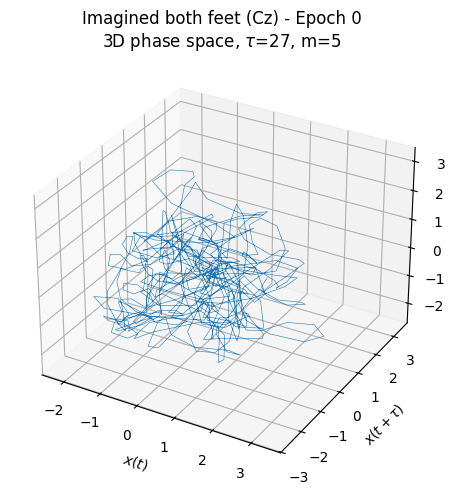

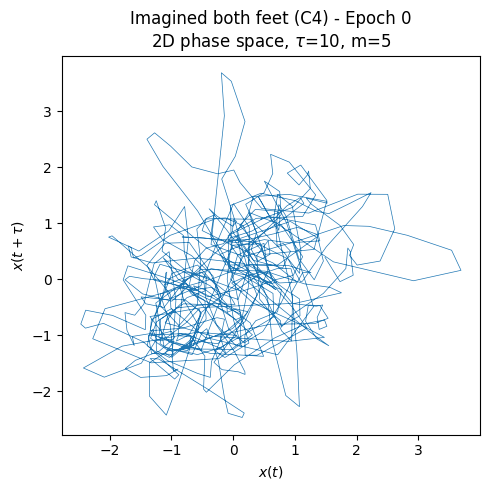

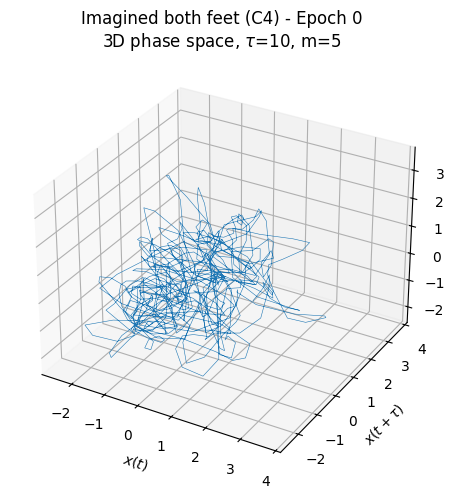

In [23]:
from mpl_toolkits.mplot3d import Axes3D

def plot_phase_space_comparison_mi(
    epochs,
    condition,
    channel,
    tau,
    m,
    class_names,
    epoch_idx=0,
    n_points=1000,
):

    ep = epochs[condition][epoch_idx].copy().pick([channel])

    x = ep.get_data()[0, 0] * 1e6
    x = (x - np.mean(x)) / np.std(x)

    X = delay_embedding(x, m=m, tau=tau)
    pts = min(n_points, len(X))

    Xs = X[:pts]

    # ---------- 2D ----------
    plt.figure(figsize=(5, 5))

    plt.plot(Xs[:, 0], Xs[:, 1], lw=0.5)

    plt.xlabel(r"$x(t)$")
    plt.ylabel(r"$x(t+\tau)$")
    plt.title(
        f"{class_names[condition]} ({channel}) - Epoch {epoch_idx}\n"
        f"2D phase space, $\\tau$={tau}, m={m}"
    )

    plt.tight_layout()
    plt.show()

    # ---------- 3D ----------
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(
        Xs[:, 0],
        Xs[:, 1],
        Xs[:, 2],
        lw=0.4,
    )

    ax.set_xlabel(r"$x(t)$")
    ax.set_ylabel(r"$x(t+\tau)$")
    ax.set_zlabel(r"$x(t+2\tau)$")
    ax.set_title(
        f"{class_names[condition]} ({channel}) - Epoch {epoch_idx}\n"
        f"3D phase space, $\\tau$={tau}, m={m}"
    )

    plt.tight_layout()
    plt.show()

for condition in ["T1", "T2"]:
    for channel in ["C3", "Cz", "C4"]:

        params = embedding_params_mi[condition][channel]

        plot_phase_space_comparison_mi(
            epochs=epochs_mi,
            condition=condition,
            channel=channel,
            tau=params["tau"],
            m=params["m"],
            class_names=class_names,
            epoch_idx=0,
            n_points=1000,
        )

#### Phase-space reconstruction of the delta band

The PSD showed that the **delta band (1–4 Hz)** exhibits the most prominent low-frequency activity during the motor imagery tasks. To investigate whether this rhythmic component also has distinct nonlinear dynamics, we reconstruct the phase space using only the delta-band signal.

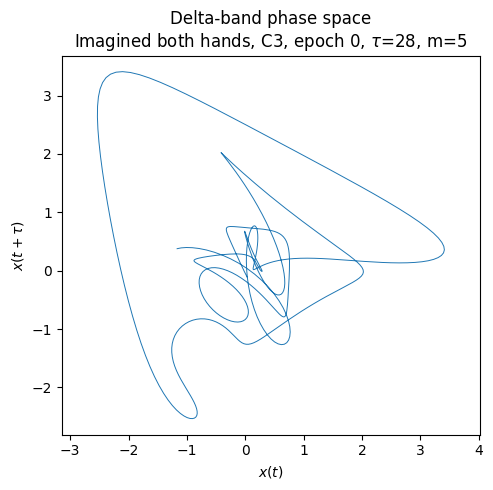

Imagined both hands, Delta, C3, τ=28, m=5: embedded=(529, 5), plotted=(529, 5)


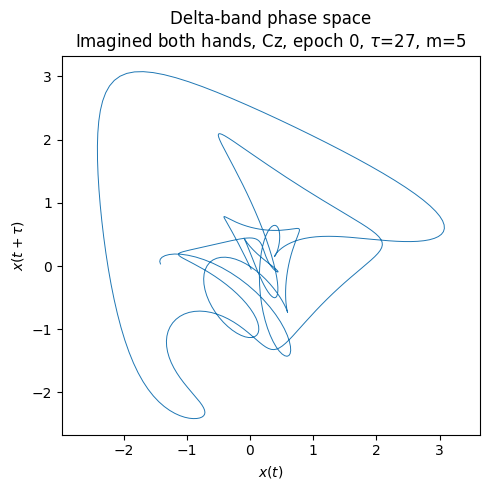

Imagined both hands, Delta, Cz, τ=27, m=5: embedded=(533, 5), plotted=(533, 5)


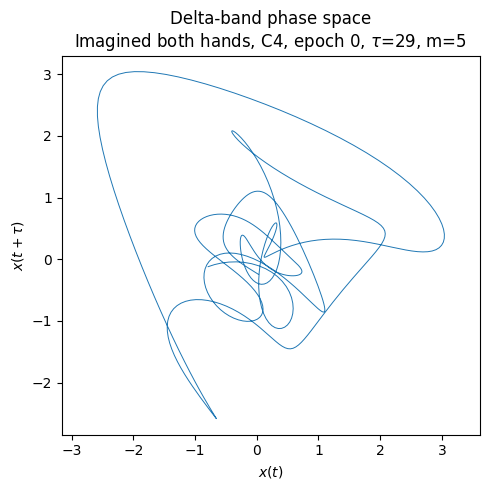

Imagined both hands, Delta, C4, τ=29, m=5: embedded=(525, 5), plotted=(525, 5)


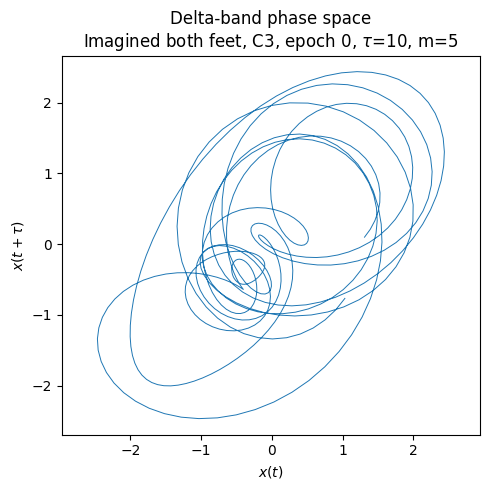

Imagined both feet, Delta, C3, τ=10, m=5: embedded=(601, 5), plotted=(601, 5)


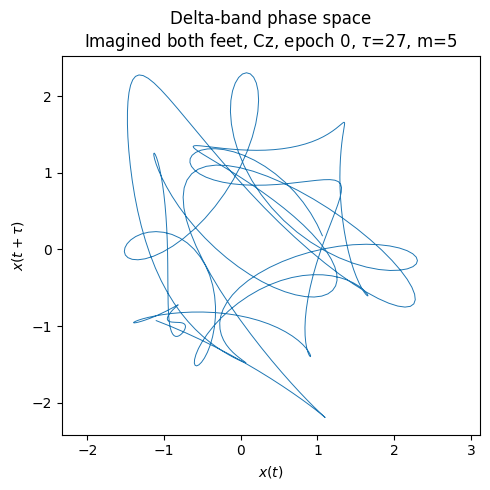

Imagined both feet, Delta, Cz, τ=27, m=5: embedded=(533, 5), plotted=(533, 5)


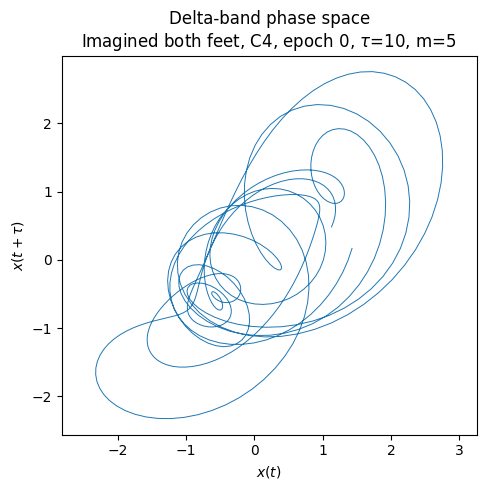

Imagined both feet, Delta, C4, τ=10, m=5: embedded=(601, 5), plotted=(601, 5)


In [24]:
def plot_band_phase_projection_mi(
    epochs,
    condition,
    channel,
    band_name,
    band_range,
    tau,
    m,
    class_names,
    epoch_idx=0,
    n_points=1000,
):
    ep = epochs[condition][epoch_idx].copy()

    ep_band = ep.filter(
        band_range[0],
        band_range[1],
        fir_design="firwin",
        verbose=False
    )

    x = ep_band.copy().pick([channel]).get_data()[0, 0] * 1e6
    x = (x - np.mean(x)) / np.std(x)

    X = delay_embedding(x, m=m, tau=tau)

    n = min(n_points, len(X))
    Xs = X[:n]

    plt.figure(figsize=(5, 5))
    plt.plot(Xs[:, 0], Xs[:, 1], linewidth=0.7)

    plt.xlabel(r"$x(t)$")
    plt.ylabel(r"$x(t+\tau)$")
    plt.title(
        f"{band_name}-band phase space\n"
        f"{class_names[condition]}, {channel}, epoch {epoch_idx}, "
        f"$\\tau$={tau}, m={m}"
    )
    plt.axis("equal")
    plt.tight_layout()
    plt.show()

    print(
        f"{class_names[condition]}, {band_name}, {channel}, "
        f"τ={tau}, m={m}: embedded={X.shape}, plotted={Xs.shape}"
    )

delta_band = (1, 4)
band_name = "Delta"
n_points = 1000

for condition in ["T1", "T2"]:
    for channel in ["C3", "Cz", "C4"]:

        params = embedding_params_mi[condition][channel]

        plot_band_phase_projection_mi(
            epochs=epochs_mi,
            condition=condition,
            channel=channel,
            band_name=band_name,
            band_range=delta_band,
            tau=params["tau"],
            m=params["m"],
            class_names=class_names,
            epoch_idx=0,
            n_points=n_points,
        )

### 2.5. Feature extraction

For each **epoch** and each channel, we compute a set of features describing the EEG signal from different perspectives:

- **Variance** (time domain)
- **Delta-band power (1–4 Hz)** (frequency domain)
- **Alpha-band power (8–13 Hz)** (frequency domain)
- **Sample entropy** (signal complexity)
- **Higuchi fractal dimension** (signal complexity)
- **Correlation dimension** (estimated dimensionality of the reconstructed attractor)
- **Largest Lyapunov exponent** (sensitivity to small perturbations in the reconstructed dynamics)

The nonlinear features based on phase-space reconstruction (correlation dimension and Lyapunov exponent) require selecting an embedding delay (**τ**) and embedding dimension (**m**). Since motor imagery is analyzed using short event-centered epochs, these features are computed **individually for each epoch** and then averaged across epochs for comparison between the two classes. The embedding dimension is fixed at **m = 5**, while the embedding delay is selected separately for each channel and condition based on the autocorrelation analysis.

In [25]:
import antropy as ant
import nolds
import numpy as np
import pandas as pd


def corr_dim_debug(x, emb_dim=5, n_points=3000):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) > n_points:
        start = max(0, len(x)//2 - n_points//2)
        x = x[start:start+n_points]

    x = (x - np.mean(x)) / np.std(x)

    try:
        return nolds.corr_dim(x, emb_dim=emb_dim)
    except Exception as e:
        print("corr_dim error:", repr(e))
        return np.nan


def lyapunov_debug(x, emb_dim=5, tau=10, n_points=3000):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) > n_points:
        start = max(0, len(x)//2 - n_points//2)
        x = x[start:start+n_points]

    x = (x - np.mean(x)) / np.std(x)

    try:
        return nolds.lyap_r(
            x,
            emb_dim=emb_dim,
            lag=tau,
            min_tsep=tau * emb_dim,
            trajectory_len=10
        )
    except Exception as e:
        print("lyap error:", repr(e))
        return np.nan


def bandpower_array(x, sfreq, fmin, fmax):
    psd, freqs = mne.time_frequency.psd_array_welch(
        x,
        sfreq=sfreq,
        fmin=fmin,
        fmax=fmax,
        verbose=False
    )

    return np.trapezoid(psd, freqs)


def extract_features_from_epochs(
    epochs,
    class_names,
    channels,
    embedding_params,
):
    sfreq = epochs.info["sfreq"]
    rows = []

    for condition in ["T1", "T2"]:
        data = epochs[condition].copy().pick(channels).get_data()
        # shape: n_epochs x n_channels x n_times

        for ep_idx, ep in enumerate(data):
            for ch_idx, ch in enumerate(channels):

                x = ep[ch_idx] * 1e6

                tau = embedding_params[condition][ch]["tau"]
                emb_dim = embedding_params[condition][ch]["m"]

                features = {
                    "condition": condition,
                    "condition_name": class_names[condition],
                    "epoch": ep_idx,
                    "channel": ch,

                    "variance": np.var(x),
                    "delta_power_1_4": bandpower_array(x, sfreq, 1, 4),
                    "alpha_power_8_13": bandpower_array(x, sfreq, 8, 13),
                    "sample_entropy": ant.sample_entropy(x),
                    "higuchi_fd": ant.higuchi_fd(x),

                    "corr_dim": corr_dim_debug(x, emb_dim=emb_dim),
                    "lyapunov": lyapunov_debug(
                        x,
                        emb_dim=emb_dim,
                        tau=tau
                    ),

                    "duration_sec": len(x) / sfreq,
                    "tau": tau,
                    "emb_dim": emb_dim,
                }

                rows.append(features)

    return pd.DataFrame(rows)

features_mi = extract_features_from_epochs(
    epochs=epochs_mi,
    class_names=class_names,
    channels=["C3", "Cz", "C4"],
    embedding_params=embedding_params_mi,
)

features_mi

C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: Un

,condition,condition_name,epoch,channel,variance,delta_power_1_4,alpha_power_8_13,sample_entropy,higuchi_fd,corr_dim,lyapunov,duration_sec,tau,emb_dim
0,T1,Imagined both hands,0,C3,3153.061461,2366.339427,71.642651,0.689925,1.476463,2.263498,0.023644,4.00625,28,5
1,T1,Imagined both hands,0,Cz,3791.298839,2466.127366,95.511737,0.818038,1.555014,2.078528,0.029568,4.00625,27,5
2,T1,Imagined both hands,0,C4,2385.129216,1773.057265,60.148093,0.803102,1.537676,1.953738,0.021571,4.00625,29,5
3,T1,Imagined both hands,1,C3,2456.550167,777.812391,97.309997,0.805847,1.470021,1.875261,0.053327,4.00625,28,5
4,T1,Imagined both hands,1,Cz,2714.212474,1028.012852,142.126979,0.783943,1.423705,1.827427,0.052683,4.00625,27,5
5,T1,Imagined both hands,1,C4,1744.554999,597.858586,107.184917,0.830336,1.438978,2.034279,0.059186,4.00625,29,5
6,T1,Imagined both hands,2,C3,6218.548340,642.360479,149.404817,0.520201,1.430266,2.468067,0.019492,4.00625,28,5
7,T1,Imagined both hands,2,Cz,5991.867076,544.863695,246.171300,0.577991,1.422317,2.328562,0.030163,4.00625,27,5
8,T1,Imagined both hands,2,C4,4719.571516,322.448361,159.527493,0.590742,1.453975,2.376855,0.037644,4.00625,29,5
9,T1,Imagined both hands,3,C3,1698.462947,854.199156,146.758533,0.954891,1.477822,1.393985,0.023626,4.00625,28,5


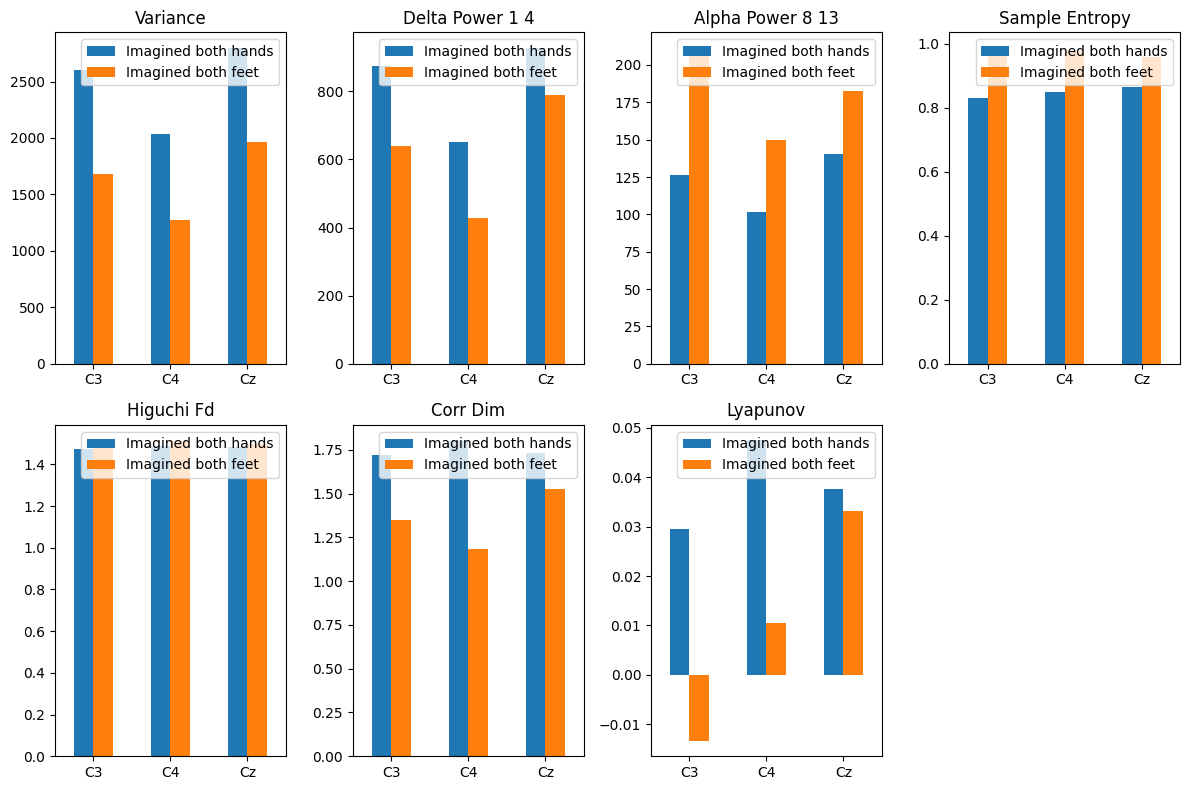

In [26]:
import matplotlib.pyplot as plt

feature_cols = [
    "variance",
    "delta_power_1_4",
    "alpha_power_8_13",
    "sample_entropy",
    "higuchi_fd",
    "corr_dim",
    "lyapunov",
]

fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()

# Average over epochs
features_mean = (
    features_mi
    .groupby(["channel", "condition"])[feature_cols]
    .mean()
    .reset_index()
)

for ax, feat in zip(axes, feature_cols):

    pivot = features_mean.pivot(
        index="channel",
        columns="condition",
        values=feat
    )

    pivot = pivot.rename(columns=class_names)

    pivot.plot(kind="bar", ax=ax)

    ax.set_title(feat.replace("_", " ").title())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="")

# Hide unused axes
for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

*Observation: In contrast to the eyes-open/eyes-closed experiment, no single feature clearly separates the two motor imagery classes. Different features capture different aspects of the EEG signal. Variance, delta-band power, correlation dimension, and the largest Lyapunov exponent tend to be higher for imagined hand movements, whereas alpha power and sample entropy are higher for imagined feet. Higuchi fractal dimension changes only slightly between the two conditions. This illustrates why motor imagery classification typically benefits from combining multiple complementary features rather than relying on a single descriptor.*

#### **REPEATED FEATURE EXTRACTION WITH CLASS-INDEPENDENT TAU (fixed value)**

C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
C:\Users\Nikolina\source\DAP_demos\.venv12\Lib\site-packages\sklearn\metrics\_regression.py:1288: Un

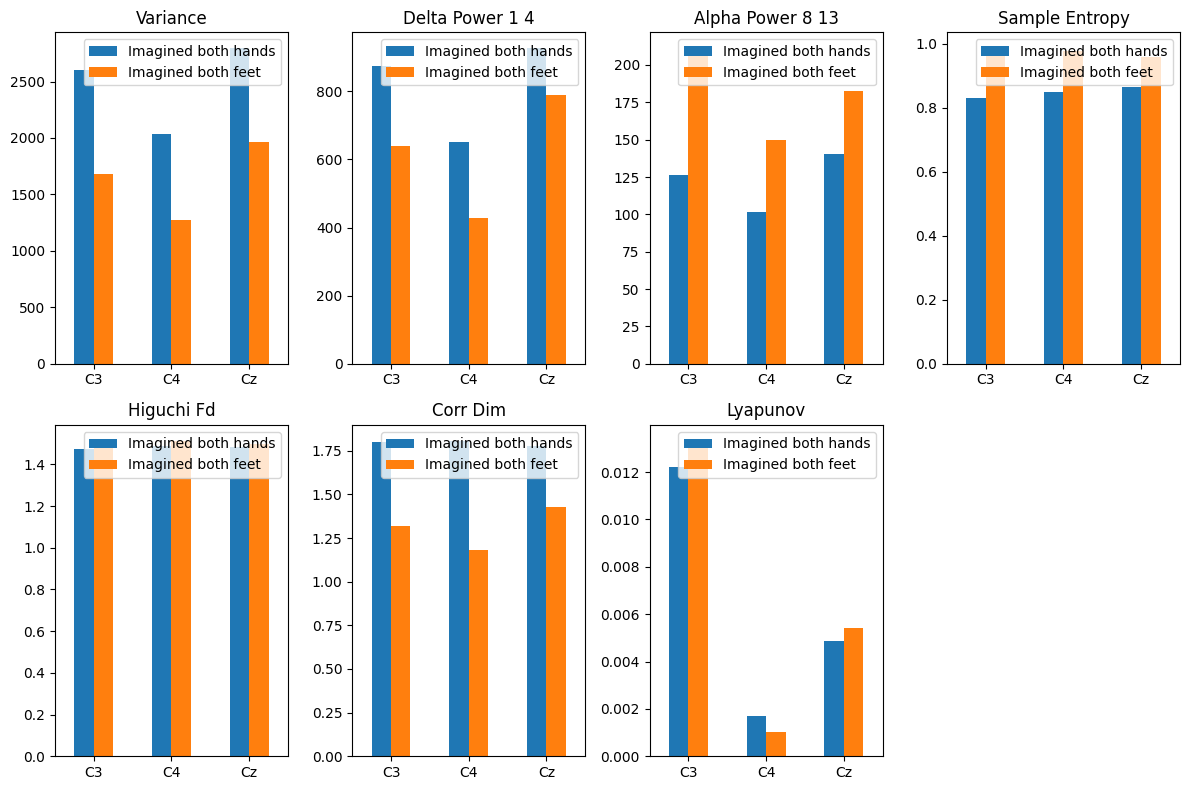

In [27]:
import antropy as ant
import nolds
import numpy as np
import pandas as pd

embedding_params_mi_2 = {
    "T1": {
        "C3": {"tau": 10, "m": m_mi},       #we pick lower tau
        "Cz": {"tau": 10, "m": m_mi},
        "C4": {"tau": 10, "m": m_mi},
    },
    "T2": {
        "C3": {"tau": 10, "m": m_mi},
        "Cz": {"tau": 10, "m": m_mi},
        "C4": {"tau": 10, "m": m_mi},
    },
}

features_mi = extract_features_from_epochs(
    epochs=epochs_mi,
    class_names=class_names,
    channels=["C3", "Cz", "C4"],
    embedding_params=embedding_params_mi_2,
)

fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()

# Average over epochs
features_mean = (
    features_mi
    .groupby(["channel", "condition"])[feature_cols]
    .mean()
    .reset_index()
)

for ax, feat in zip(axes, feature_cols):

    pivot = features_mean.pivot(
        index="channel",
        columns="condition",
        values=feat
    )

    pivot = pivot.rename(columns=class_names)

    pivot.plot(kind="bar", ax=ax)

    ax.set_title(feat.replace("_", " ").title())
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="")

# Hide unused axes
for ax in axes[len(feature_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()